# 💳 IEEE-CIS Fraud Detection 

# Part 1 - Business Problem

**🇺🇸 English**

**Context**
E-commerce fraud is one of the fastest-growing financial threats globally. Vesta Corporation processes over **$18 billion in guaranteed transactions annually**, absorbing the financial risk of fraudulent card-not-present (CNP) operations. Every undetected fraud directly impacts Vesta's bottom line and erodes merchant trust.

**Business Problem**
The current rule-based fraud detection system generates two critical failure modes:

| Failure | Business Impact |
|---|---|
| **False Negative** (missed fraud) | Direct financial loss — Vesta absorbs 100% of the transaction value |
| **False Positive** (legitimate blocked) | Customer churn, merchant dissatisfaction, support costs |

The goal is to build a machine learning model that **predicts the probability that a
transaction is fraudulent**, enabling smarter, risk-based decisioning at scale.

**Financial Metrics**

- **Average fraudulent transaction value**: ~$150–$300 USD (estimated from CNP industry benchmarks)
- **Fraud rate in dataset**: ~3.5% of transactions
- **Cost of a False Negative**: full transaction value absorbed by Vesta
- **Cost of a False Positive**: estimated $15–$25 USD in operational costs (review, support, churn risk)
- **Target metric**: Area Under the ROC Curve (**AUC-ROC**) — balances sensitivity and specificity across all decision thresholds

**Success Criteria**

| Metric | Baseline (rule-based) | Target (ML model) |
|---|---|---|
| AUC-ROC | ~0.80 | **≥ 0.92** |
| False Negative Rate | High | Minimized |
| Operational Review Load | Manual | Automated scoring |

**🇧🇷 Português**

**Contexto**
A fraude em e-commerce é uma das ameaças financeiras de crescimento mais rápido no mundo. A Vesta Corporation processa mais de **US$ 18 bilhões em transações garantidas anualmente**, absorvendo o risco financeiro de operações fraudulentas sem presença física do cartão (CNP). Cada fraude não detectada impacta diretamente o resultado financeiro da Vesta e corrói a confiança dos comerciantes parceiros.

**Problema de Negócio**
O sistema atual baseado em regras gera dois modos críticos de falha:

| Falha | Impacto no Negócio |
|---|---|
| **Falso Negativo** (fraude não detectada) | Perda financeira direta — Vesta absorve 100% do valor da transação |
| **Falso Positivo** (legítima bloqueada) | Churn de clientes, insatisfação de comerciantes, custos de suporte |

O objetivo é construir um modelo de machine learning que **preveja a probabilidade de uma
transação ser fraudulenta**, viabilizando decisões baseadas em risco em larga escala.

**Métricas Financeiras**

- **Valor médio de transação fraudulenta**: ~US$ 150–300 (estimativa com base em benchmarks CNP)
- **Taxa de fraude no dataset**: ~3,5% das transações
- **Custo de um Falso Negativo**: valor integral da transação absorvido pela Vesta
- **Custo de um Falso Positivo**: estimativa de US$ 15–25 em custos operacionais (revisão, suporte, risco de churn)
- **Métrica alvo**: Área sob a Curva ROC (**AUC-ROC**) — equilibra sensibilidade e especificidade em todos os limiares de decisão

**Critérios de Sucesso**

| Métrica | Baseline (regras) | Alvo (modelo ML) |
|---|---|---|
| AUC-ROC | ~0,80 | **≥ 0,92** |
| Taxa de Falso Negativo | Alta | Minimizada |
| Carga de Revisão Operacional | Manual | Scoring automatizado |

In [1]:
"""
IEEE-CIS Fraud Detection — Consolidated Imports
================================================
All libraries used across the full pipeline:
EDA, balancing, dimensionality reduction, modeling, evaluation, and saving.
"""

import os
import json
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

from datetime import datetime
from collections import Counter
from scipy import stats

from sklearn.preprocessing       import RobustScaler
from sklearn.model_selection     import StratifiedKFold, cross_val_score, cross_val_predict
from sklearn.decomposition       import PCA, TruncatedSVD
from sklearn.manifold            import TSNE
from sklearn.linear_model        import LogisticRegression
from sklearn.neighbors           import KNeighborsClassifier
from sklearn.tree                import DecisionTreeClassifier
from sklearn.ensemble            import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics             import (
    roc_auc_score, f1_score, precision_score,
    recall_score, accuracy_score, confusion_matrix,
    precision_recall_curve, roc_curve, classification_report
)

from imblearn.under_sampling     import RandomUnderSampler
from imblearn.over_sampling      import SMOTE

from xgboost                     import XGBClassifier
from lightgbm                    import LGBMClassifier
from catboost                    import CatBoostClassifier

import joblib

warnings.filterwarnings("ignore")

# Part 2 - Database

In [2]:
# PATHS
from pathlib import Path

BASE_PATH = Path("/kaggle/input/competitions/ieee-fraud-detection")

TRAIN_TRANSACTION = BASE_PATH / "train_transaction.csv"
TRAIN_IDENTITY    = BASE_PATH / "train_identity.csv"
TEST_TRANSACTION  = BASE_PATH / "test_transaction.csv"
TEST_IDENTITY     = BASE_PATH / "test_identity.csv"
SAMPLE_SUB        = BASE_PATH / "sample_submission.csv"

# LOAD DATASETS
print("Loading datasets...")

train_transaction = pd.read_csv(TRAIN_TRANSACTION)
train_identity    = pd.read_csv(TRAIN_IDENTITY)
test_transaction  = pd.read_csv(TEST_TRANSACTION)
test_identity     = pd.read_csv(TEST_IDENTITY)
sample_sub        = pd.read_csv(SAMPLE_SUB)

print("Datasets loaded successfully.")

Loading datasets...
Datasets loaded successfully.


In [3]:
# MERGE — transaction + identity on TransactionID
train = train_transaction.merge(train_identity, on="TransactionID", how="left")
test  = test_transaction.merge(test_identity,   on="TransactionID", how="left")

# View
train.head()

,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,...,id_31,id_32,id_33,id_34,id_35,id_36,id_37,id_38,DeviceType,DeviceInfo
0,2987000,0,86400,68.5,W,13926,NaN,150.0,discover,142.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2987001,0,86401,29.0,W,2755,404.0,150.0,mastercard,102.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2987002,0,86469,59.0,W,4663,490.0,150.0,visa,166.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2987003,0,86499,50.0,W,18132,567.0,150.0,mastercard,117.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2987004,0,86506,50.0,H,4497,514.0,150.0,mastercard,102.0,...,samsung browser 6.2,32.0,2220x1080,match_status:2,T,F,T,T,mobile,SAMSUNG SM-G892A Build/NRD90M


In [4]:
print(f"Train shape: {train.shape}")
print(f"Test shape:  {test.shape}")

Train shape: (590540, 434)
Test shape:  (506691, 433)


In [5]:
# QUICK SANITY CHECK
print("\n--- Train sample ---")
display(train.head(3))


--- Train sample ---


,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,...,id_31,id_32,id_33,id_34,id_35,id_36,id_37,id_38,DeviceType,DeviceInfo
0,2987000,0,86400,68.5,W,13926,NaN,150.0,discover,142.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2987001,0,86401,29.0,W,2755,404.0,150.0,mastercard,102.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2987002,0,86469,59.0,W,4663,490.0,150.0,visa,166.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [6]:
#print("\n--- Target distribution ---")
fraud_counts = train["isFraud"].value_counts()
fraud_rate   = train["isFraud"].mean() * 100

In [7]:
print(fraud_counts)
print(f"\nFraud rate: {fraud_rate:.2f}%")

isFraud
0    569877
1     20663
Name: count, dtype: int64

Fraud rate: 3.50%


In [8]:
# MEMORY USAGE
print("\n--- Memory usage ---")
print(f"Train: {train.memory_usage(deep=True).sum() / 1e6:.2f} MB")
print(f"Test:  {test.memory_usage(deep=True).sum() / 1e6:.2f} MB")


--- Memory usage ---
Train: 2636.09 MB
Test:  2269.22 MB


# Part 3 - Memory Optimization

In [9]:
"""
IEEE-CIS Fraud Detection — Memory Optimization & EDA
=====================================================
Reduces memory footprint by downcasting numeric dtypes.
"""

# MEMORY OPTIMIZATION FUNCTION
def reduce_memory(df: pd.DataFrame, verbose: bool = True) -> pd.DataFrame:
    """
    Downcast numeric columns to reduce DataFrame memory usage.

    Parameters
    ----------
    df : pd.DataFrame
        Input DataFrame to optimize.
    verbose : bool
        If True, prints memory reduction summary.

    Returns
    -------
    pd.DataFrame
        DataFrame with optimized dtypes.
    """
    start_mem = df.memory_usage(deep=True).sum() / 1e6

    for col in df.columns:
        col_type = df[col].dtype

        if col_type != object:
            c_min = df[col].min()
            c_max = df[col].max()

            if str(col_type)[:3] == "int":
                if c_min > np.iinfo(np.int8).min and c_max < np.iinfo(np.int8).max:
                    df[col] = df[col].astype(np.int8)
                elif c_min > np.iinfo(np.int16).min and c_max < np.iinfo(np.int16).max:
                    df[col] = df[col].astype(np.int16)
                elif c_min > np.iinfo(np.int32).min and c_max < np.iinfo(np.int32).max:
                    df[col] = df[col].astype(np.int32)
                else:
                    df[col] = df[col].astype(np.int64)

            else:
                if c_min > np.finfo(np.float16).min and c_max < np.finfo(np.float16).max:
                    df[col] = df[col].astype(np.float32)
                elif c_min > np.finfo(np.float32).min and c_max < np.finfo(np.float32).max:
                    df[col] = df[col].astype(np.float32)
                else:
                    df[col] = df[col].astype(np.float64)

    end_mem = df.memory_usage(deep=True).sum() / 1e6

    if verbose:
        reduction = 100 * (start_mem - end_mem) / start_mem
        print(f"Memory: {start_mem:.2f} MB → {end_mem:.2f} MB ({reduction:.1f}% reduction)")

    return df

In [10]:
# APPLY MEMORY OPTIMIZATION
print("Optimizing train...")
train = reduce_memory(train)

Optimizing train...
Memory: 2636.09 MB → 1681.19 MB (36.2% reduction)


In [11]:
print("Optimizing test...")
test = reduce_memory(test)

Optimizing test...
Memory: 2269.22 MB → 1453.45 MB (35.9% reduction)


In [12]:
# EDA — MISSING VALUES OVERVIEW
def missing_summary(df: pd.DataFrame, label: str) -> pd.DataFrame:
    """
    Returns a sorted summary of missing values per column.

    Parameters
    ----------
    df : pd.DataFrame
        DataFrame to analyze.
    label : str
        Label used in the printed header.

    Returns
    -------
    pd.DataFrame
        DataFrame with columns: missing_count, missing_pct.
    """
    missing = df.isnull().sum()
    missing = missing[missing > 0]
    result = pd.DataFrame({
        "missing_count": missing,
        "missing_pct":   (missing / len(df) * 100).round(2)
    }).sort_values("missing_pct", ascending=False)

    print(f"\n--- Missing values: {label} ({len(result)} columns with nulls) ---")
    return result

In [13]:
train_missing = missing_summary(train, "Train")
display(train_missing.head(20))


--- Missing values: Train (414 columns with nulls) ---


,missing_count,missing_pct
id_24,585793,99.20
id_26,585377,99.13
id_25,585408,99.13
id_21,585381,99.13
id_07,585385,99.13
id_08,585385,99.13
id_23,585371,99.12
id_22,585371,99.12
id_27,585371,99.12
dist2,552913,93.63


In [14]:
test_missing = missing_summary(test, "Test")
display(test_missing.head(20))


--- Missing values: Test (385 columns with nulls) ---


,missing_count,missing_pct
id-24,501951,99.06
id-25,501652,99.01
id-08,501632,99.00
id-22,501629,99.00
id-21,501632,99.00
id-07,501632,99.00
id-27,501629,99.00
id-26,501644,99.00
id-23,501629,99.00
dist2,470255,92.81


# Part 4 - EDA

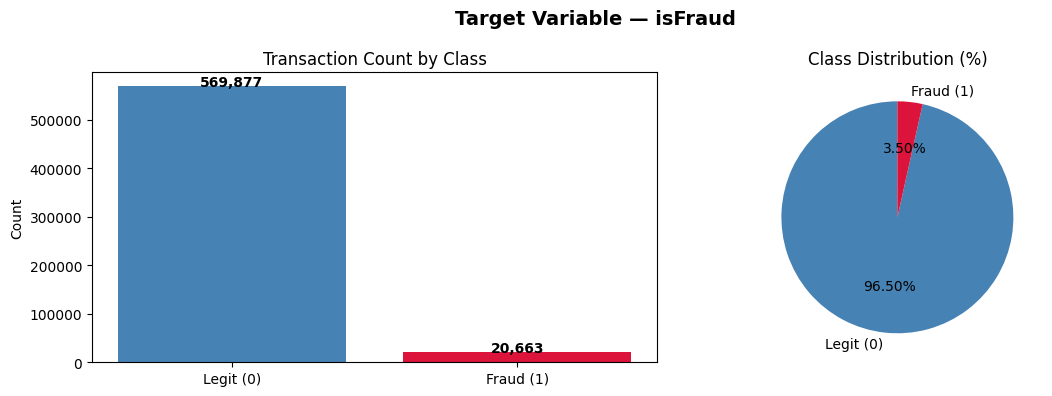

In [15]:
# EDA — TARGET DISTRIBUTION PLOT
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

fraud_counts = train["isFraud"].value_counts()
axes[0].bar(
    ["Legit (0)", "Fraud (1)"],
    fraud_counts.values,
    color=["steelblue", "crimson"]
)
axes[0].set_title("Transaction Count by Class")
axes[0].set_ylabel("Count")
for i, v in enumerate(fraud_counts.values):
    axes[0].text(i, v + 1000, f"{v:,}", ha="center", fontweight="bold")

axes[1].pie(
    fraud_counts.values,
    labels=["Legit (0)", "Fraud (1)"],
    autopct="%1.2f%%",
    colors=["steelblue", "crimson"],
    startangle=90
)
axes[1].set_title("Class Distribution (%)")

plt.suptitle("Target Variable — isFraud", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

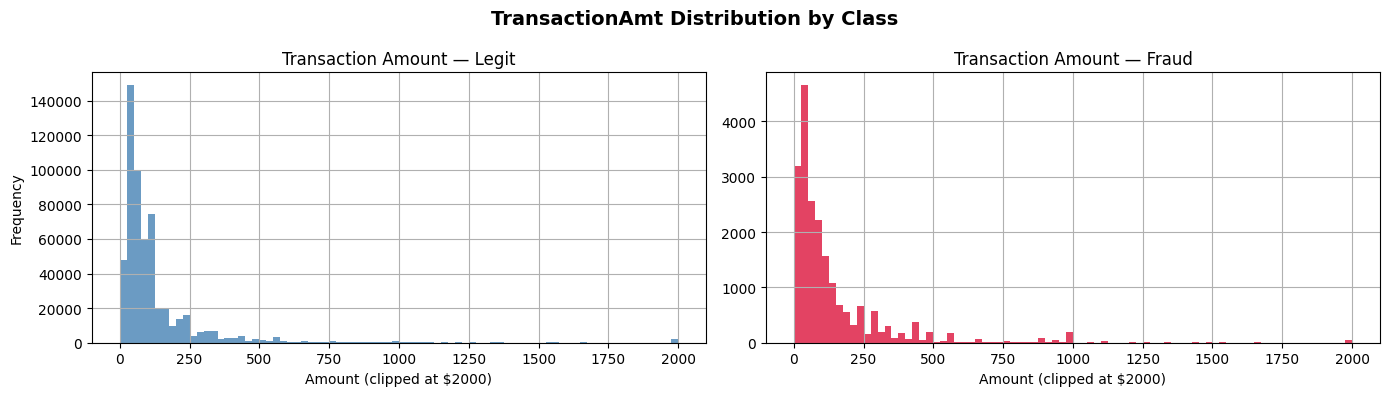

In [16]:
# EDA — TRANSACTION AMOUNT DISTRIBUTION
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

train[train["isFraud"] == 0]["TransactionAmt"].clip(upper=2000).hist(
    bins=80, ax=axes[0], color="steelblue", alpha=0.8
)
axes[0].set_title("Transaction Amount — Legit")
axes[0].set_xlabel("Amount (clipped at $2000)")
axes[0].set_ylabel("Frequency")

train[train["isFraud"] == 1]["TransactionAmt"].clip(upper=2000).hist(
    bins=80, ax=axes[1], color="crimson", alpha=0.8
)
axes[1].set_title("Transaction Amount — Fraud")
axes[1].set_xlabel("Amount (clipped at $2000)")

plt.suptitle("TransactionAmt Distribution by Class", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

In [17]:
# EDA — TRANSACTION AMOUNT STATS BY CLASS
print("\n--- TransactionAmt stats by isFraud ---")
display(
    train.groupby("isFraud")["TransactionAmt"]
    .describe()
    .round(2)
)


--- TransactionAmt stats by isFraud ---


,count,mean,std,min,25%,50%,75%,max
isFraud,,,,,,,,
0,569877.0,134.51,239.40,0.25,43.97,68.5,120.0,31937.39
1,20663.0,149.24,232.21,0.29,35.04,75.0,161.0,5191.00


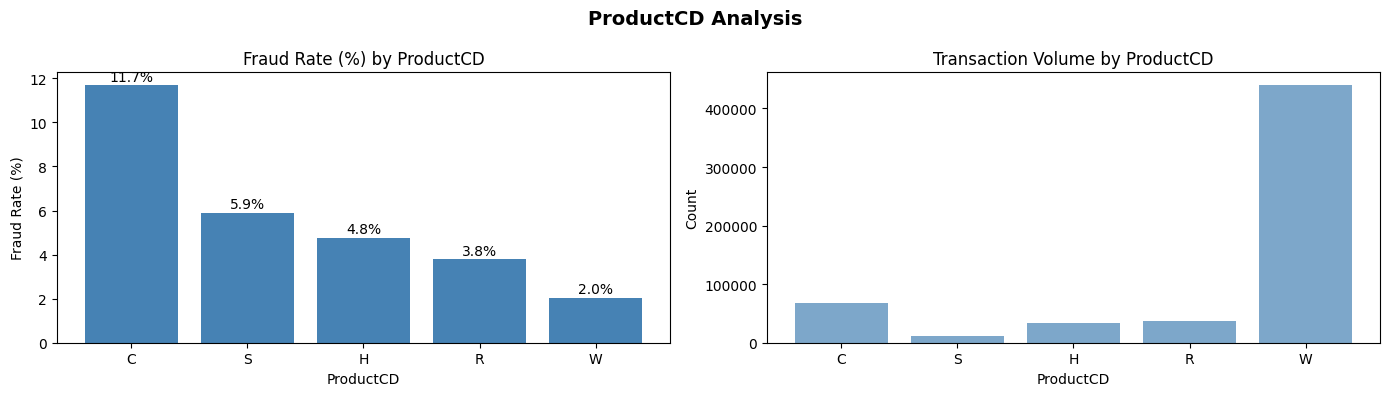

,fraud_rate,total,fraud_rate_pct
ProductCD,,,
C,0.116873,68519,11.687269
S,0.058996,11628,5.899553
H,0.047662,33024,4.766231
R,0.037826,37699,3.782594
W,0.020399,439670,2.039939


In [18]:
"""
IEEE-CIS Fraud Detection — EDA Categorical & Time Features
===========================================================
Analyzes fraud rate by key categorical features and transaction time patterns.
"""

# FRAUD RATE BY PRODUCT CODE
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

product_fraud = (
    train.groupby("ProductCD")["isFraud"]
    .agg(["mean", "count"])
    .rename(columns={"mean": "fraud_rate", "count": "total"})
    .sort_values("fraud_rate", ascending=False)
)
product_fraud["fraud_rate_pct"] = product_fraud["fraud_rate"] * 100

axes[0].bar(product_fraud.index, product_fraud["fraud_rate_pct"], color="steelblue")
axes[0].set_title("Fraud Rate (%) by ProductCD")
axes[0].set_ylabel("Fraud Rate (%)")
axes[0].set_xlabel("ProductCD")
for i, (idx, row) in enumerate(product_fraud.iterrows()):
    axes[0].text(i, row["fraud_rate_pct"] + 0.2, f'{row["fraud_rate_pct"]:.1f}%', ha="center")

axes[1].bar(product_fraud.index, product_fraud["total"], color="steelblue", alpha=0.7)
axes[1].set_title("Transaction Volume by ProductCD")
axes[1].set_ylabel("Count")
axes[1].set_xlabel("ProductCD")

plt.suptitle("ProductCD Analysis", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

display(product_fraud)

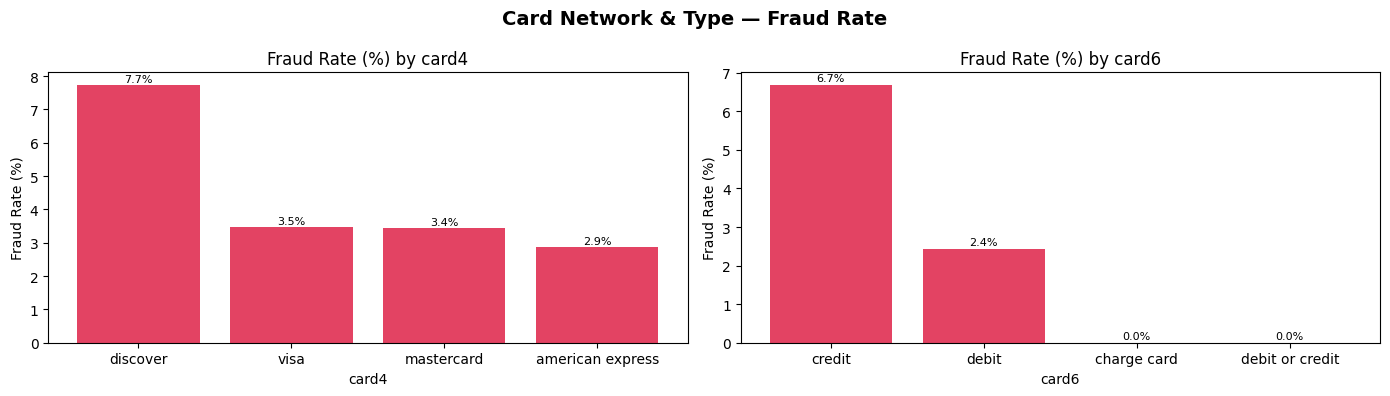

In [19]:
# FRAUD RATE BY CARD TYPE (card4 = network, card6 = type)
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for ax, col in zip(axes, ["card4", "card6"]):
    card_fraud = (
        train.groupby(col)["isFraud"]
        .agg(["mean", "count"])
        .rename(columns={"mean": "fraud_rate", "count": "total"})
        .sort_values("fraud_rate", ascending=False)
    )
    card_fraud["fraud_rate_pct"] = card_fraud["fraud_rate"] * 100

    ax.bar(card_fraud.index, card_fraud["fraud_rate_pct"], color="crimson", alpha=0.8)
    ax.set_title(f"Fraud Rate (%) by {col}")
    ax.set_ylabel("Fraud Rate (%)")
    ax.set_xlabel(col)
    for i, (idx, row) in enumerate(card_fraud.iterrows()):
        ax.text(i, row["fraud_rate_pct"] + 0.1, f'{row["fraud_rate_pct"]:.1f}%', ha="center", fontsize=8)

plt.suptitle("Card Network & Type — Fraud Rate", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

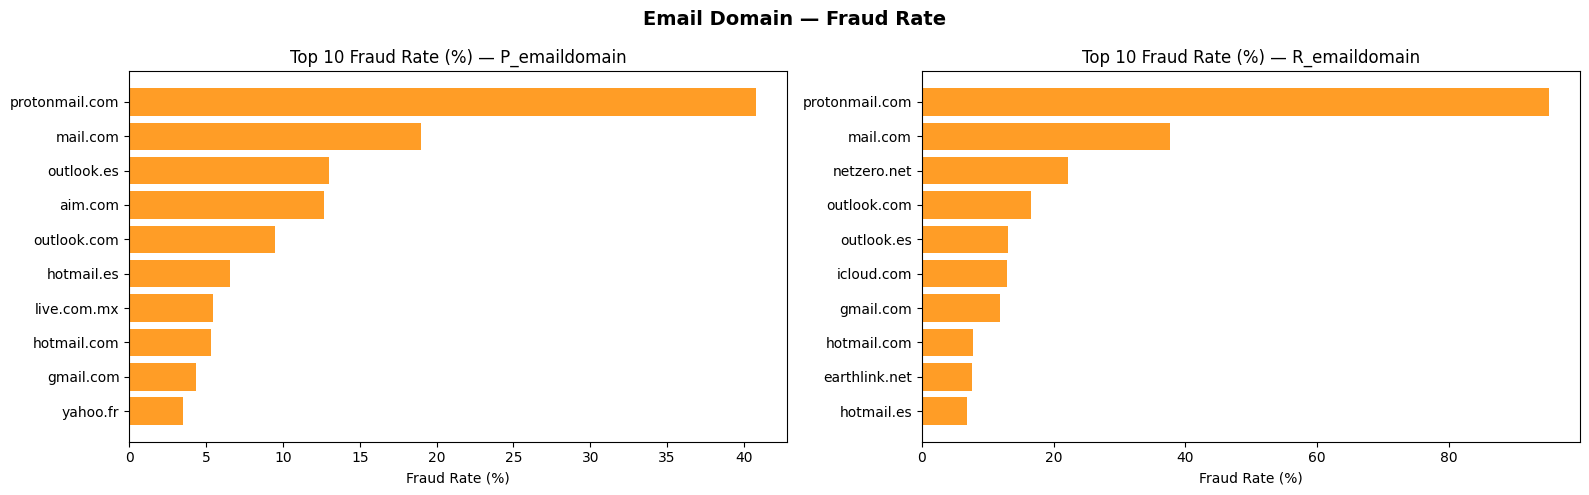

In [20]:
# FRAUD RATE BY EMAIL DOMAIN (top 10)
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, col in zip(axes, ["P_emaildomain", "R_emaildomain"]):
    email_fraud = (
        train.groupby(col)["isFraud"]
        .agg(["mean", "count"])
        .rename(columns={"mean": "fraud_rate", "count": "total"})
    )
    email_fraud["fraud_rate_pct"] = email_fraud["fraud_rate"] * 100
    top10 = email_fraud.nlargest(10, "fraud_rate_pct")

    ax.barh(top10.index, top10["fraud_rate_pct"], color="darkorange", alpha=0.85)
    ax.set_title(f"Top 10 Fraud Rate (%) — {col}")
    ax.set_xlabel("Fraud Rate (%)")
    ax.invert_yaxis()

plt.suptitle("Email Domain — Fraud Rate", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

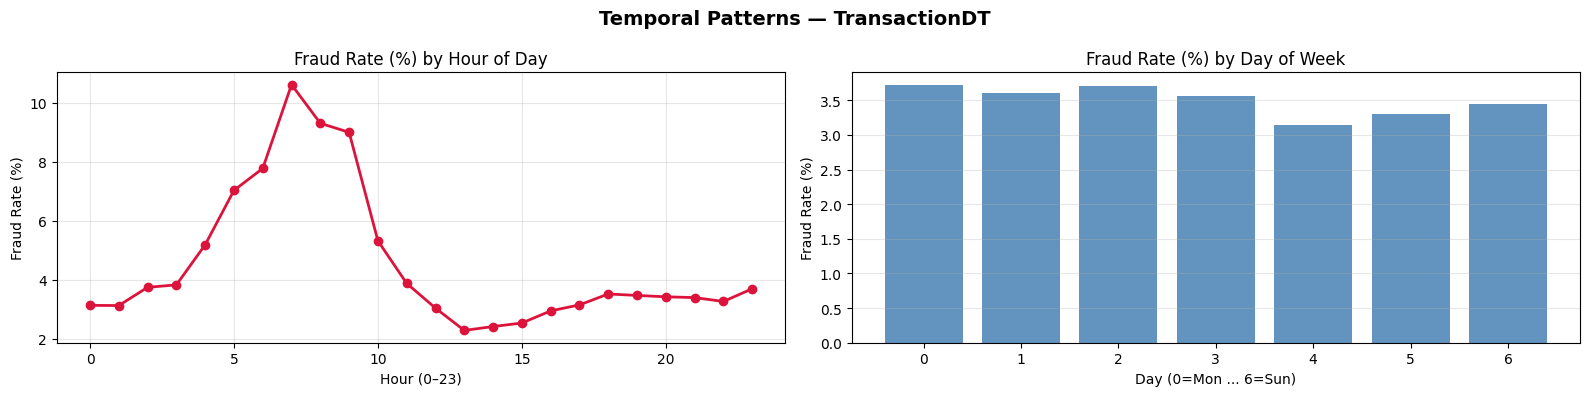

In [21]:
# TIME FEATURE — TransactionDT → hour of day & day of week
train["hour"] = (train["TransactionDT"] // 3600) % 24
train["day"]  = (train["TransactionDT"] // (3600 * 24)) % 7

test["hour"] = (test["TransactionDT"] // 3600) % 24
test["day"]  = (test["TransactionDT"] // (3600 * 24)) % 7

fig, axes = plt.subplots(1, 2, figsize=(16, 4))

hour_fraud = train.groupby("hour")["isFraud"].mean() * 100
axes[0].plot(hour_fraud.index, hour_fraud.values, color="crimson", marker="o", linewidth=2)
axes[0].set_title("Fraud Rate (%) by Hour of Day")
axes[0].set_xlabel("Hour (0–23)")
axes[0].set_ylabel("Fraud Rate (%)")
axes[0].grid(True, alpha=0.3)

day_fraud = train.groupby("day")["isFraud"].mean() * 100
axes[1].bar(day_fraud.index, day_fraud.values, color="steelblue", alpha=0.85)
axes[1].set_title("Fraud Rate (%) by Day of Week")
axes[1].set_xlabel("Day (0=Mon ... 6=Sun)")
axes[1].set_ylabel("Fraud Rate (%)")
axes[1].grid(True, alpha=0.3, axis="y")

plt.suptitle("Temporal Patterns — TransactionDT", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

In [22]:
# SUMMARY TABLE — hour & day
print("\n--- Fraud Rate by Hour (top 5 riskiest) ---")
display(hour_fraud.sort_values(ascending=False).head(5).round(2).to_frame("fraud_rate_pct"))


--- Fraud Rate by Hour (top 5 riskiest) ---


,fraud_rate_pct
hour,
7,10.61
8,9.30
9,9.00
6,7.77
5,7.03


In [23]:
print("\n--- Fraud Rate by Day ---")
display(day_fraud.round(2).to_frame("fraud_rate_pct"))


--- Fraud Rate by Day ---


,fraud_rate_pct
day,
0,3.72
1,3.60
2,3.71
3,3.56
4,3.15
5,3.30
6,3.45


In [24]:
"""
IEEE-CIS Fraud Detection — EDA Class Distribution
==================================================
Maps binary fraud label and displays class distribution summary.
"""

# LABEL HELPER
def label_fraud(value: int) -> str:
    """
    Maps binary fraud label to human-readable string.

    Parameters
    ----------
    value : int
        Binary target value (0 or 1).

    Returns
    -------
    str
        'Legitimate' for 0, 'Fraud' for 1.
    """
    return "Legitimate" if value == 0 else "Fraud"

# CLASS DISTRIBUTION
print("Transactions without fraud:", train["isFraud"].value_counts()[0])
print("Transactions with fraud   :", train["isFraud"].value_counts()[1])
print()
print("Transactions without fraud:", round(train["isFraud"].value_counts()[0] / len(train) * 100, 2), "% of sample")
print("Transactions with fraud   :", round(train["isFraud"].value_counts()[1] / len(train) * 100, 2), "% of sample")

train_tmp = train[["isFraud"]].copy()
train_tmp["isFraud"] = train_tmp["isFraud"].apply(label_fraud)

Transactions without fraud: 569877
Transactions with fraud   : 20663

Transactions without fraud: 96.5 % of sample
Transactions with fraud   : 3.5 % of sample


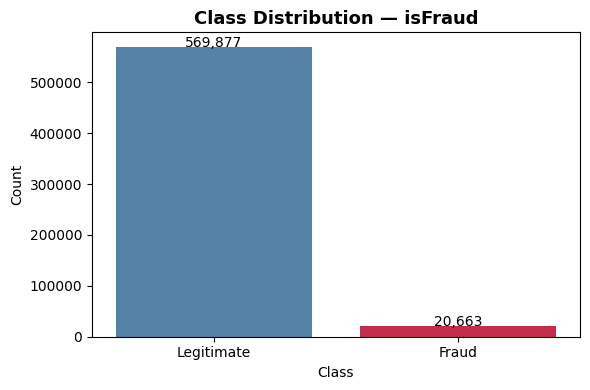

In [25]:
# CLASS DISTRIBUTION PLOT
fig, ax = plt.subplots(figsize=(6, 4))

sns.countplot(
    data=train_tmp,
    x="isFraud",
    palette={"Legitimate": "steelblue", "Fraud": "crimson"},
    ax=ax
)

ax.set_title("Class Distribution — isFraud", fontsize=13, fontweight="bold")
ax.set_xlabel("Class")
ax.set_ylabel("Count")

for p in ax.patches:
    ax.annotate(
        f"{int(p.get_height()):,}",
        (p.get_x() + p.get_width() / 2, p.get_height() + 500),
        ha="center",
        fontsize=10
    )

plt.tight_layout()
plt.show()
del train_tmp

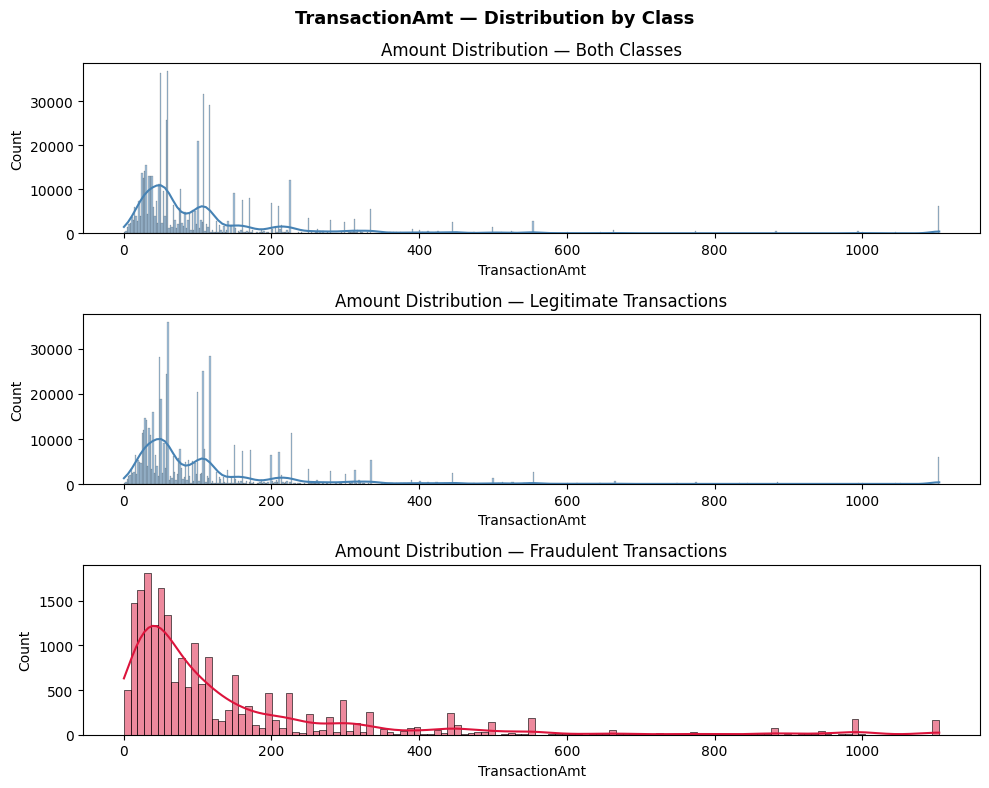

In [26]:
# DISTRIBUTION — TransactionAmt by class
fig, axes = plt.subplots(3, 1, figsize=(10, 8))

amt_clip = train["TransactionAmt"].clip(upper=train["TransactionAmt"].quantile(0.99))

sns.histplot(amt_clip, ax=axes[0], color="steelblue", kde=True)
axes[0].set_title("Amount Distribution — Both Classes", fontsize=12)
axes[0].set_xlabel("TransactionAmt")

sns.histplot(
    train[train["isFraud"] == 0]["TransactionAmt"].clip(upper=train["TransactionAmt"].quantile(0.99)),
    ax=axes[1], color="steelblue", kde=True
)
axes[1].set_title("Amount Distribution — Legitimate Transactions", fontsize=12)
axes[1].set_xlabel("TransactionAmt")

sns.histplot(
    train[train["isFraud"] == 1]["TransactionAmt"].clip(upper=train["TransactionAmt"].quantile(0.99)),
    ax=axes[2], color="crimson", kde=True
)
axes[2].set_title("Amount Distribution — Fraudulent Transactions", fontsize=12)
axes[2].set_xlabel("TransactionAmt")

plt.suptitle("TransactionAmt — Distribution by Class", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

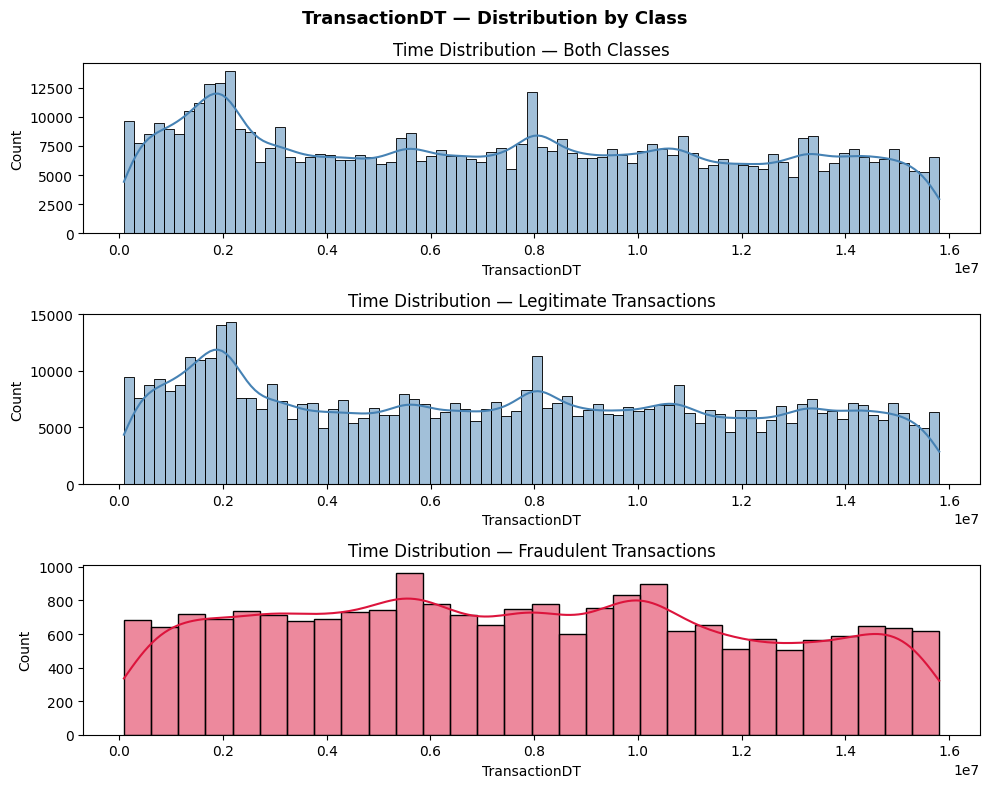

In [27]:
# DISTRIBUTION — TransactionDT by class
fig, axes = plt.subplots(3, 1, figsize=(10, 8))

sns.histplot(train["TransactionDT"], ax=axes[0], color="steelblue", kde=True)
axes[0].set_title("Time Distribution — Both Classes", fontsize=12)
axes[0].set_xlabel("TransactionDT")

sns.histplot(train[train["isFraud"] == 0]["TransactionDT"], ax=axes[1], color="steelblue", kde=True)
axes[1].set_title("Time Distribution — Legitimate Transactions", fontsize=12)
axes[1].set_xlabel("TransactionDT")

sns.histplot(train[train["isFraud"] == 1]["TransactionDT"], ax=axes[2], color="crimson", kde=True)
axes[2].set_title("Time Distribution — Fraudulent Transactions", fontsize=12)
axes[2].set_xlabel("TransactionDT")

plt.suptitle("TransactionDT — Distribution by Class", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

# Part 4.1 -  EAD Fraud Score Analysis

In [28]:
"""
IEEE-CIS Fraud Detection — Fraud Score Analysis
================================================
Combines Target Encoding (fraud rate) and Frequency Encoding
into a single normalized fraud risk score per transaction.
"""

from sklearn.preprocessing import MinMaxScaler

# TARGET ENCODING — fraud rate per category
def target_encode(df_train: pd.DataFrame, df_test: pd.DataFrame, col: str) -> tuple:
    """
    Computes fraud rate per category from train and maps to both train and test.

    Parameters
    ----------
    df_train : pd.DataFrame
        Training DataFrame containing isFraud column.
    df_test : pd.DataFrame
        Test DataFrame to receive encoded values.
    col : str
        Categorical column to encode.

    Returns
    -------
    tuple
        Two pd.Series with encoded values for train and test.
    """
    fraud_rate = df_train.groupby(col)["isFraud"].mean()
    train_enc  = df_train[col].map(fraud_rate).fillna(fraud_rate.mean())
    test_enc   = df_test[col].map(fraud_rate).fillna(fraud_rate.mean())
    return train_enc, test_enc


# FREQUENCY ENCODING — transaction volume per category
def frequency_encode(df_train: pd.DataFrame, df_test: pd.DataFrame, col: str) -> tuple:
    """
    Computes normalized transaction frequency per category from train.

    Parameters
    ----------
    df_train : pd.DataFrame
        Training DataFrame.
    df_test : pd.DataFrame
        Test DataFrame to receive encoded values.
    col : str
        Categorical column to encode.

    Returns
    -------
    tuple
        Two pd.Series with frequency-encoded values for train and test.
    """
    freq       = df_train[col].value_counts(normalize=True)
    train_enc  = df_train[col].map(freq).fillna(0)
    test_enc   = df_test[col].map(freq).fillna(0)
    return train_enc, test_enc

# FEATURES ENTERING THE SCORE
score_features = ["ProductCD", "card4", "card6", "P_emaildomain", "R_emaildomain", "hour", "day"]

target_enc_train = pd.DataFrame(index=train.index)
target_enc_test  = pd.DataFrame(index=test.index)
freq_enc_train   = pd.DataFrame(index=train.index)
freq_enc_test    = pd.DataFrame(index=test.index)

for col in score_features:
    te_tr, te_te = target_encode(train, test, col)
    target_enc_train[f"te_{col}"] = te_tr
    target_enc_test[f"te_{col}"]  = te_te

    fe_tr, fe_te = frequency_encode(train, test, col)
    freq_enc_train[f"fe_{col}"] = fe_tr
    freq_enc_test[f"fe_{col}"]  = fe_te

# NORMALIZE EACH ENCODING TO [0, 1]
scaler = MinMaxScaler()

te_train_scaled = scaler.fit_transform(target_enc_train)
te_test_scaled  = scaler.transform(target_enc_test)

scaler_freq = MinMaxScaler()

fe_train_scaled = scaler_freq.fit_transform(freq_enc_train)
fe_test_scaled  = scaler_freq.transform(freq_enc_test)

In [29]:
# FRAUD SCORE — weighted average (target enc 70% + freq enc 30%)
WEIGHT_TARGET = 0.7
WEIGHT_FREQ   = 0.3

train["fraud_score"] = (
    WEIGHT_TARGET * te_train_scaled.mean(axis=1) +
    WEIGHT_FREQ   * fe_train_scaled.mean(axis=1)
)

test["fraud_score"] = (
    WEIGHT_TARGET * te_test_scaled.mean(axis=1) +
    WEIGHT_FREQ   * fe_test_scaled.mean(axis=1)
)

# SCORE DISTRIBUTION BY CLASS
print("--- Fraud Score stats by isFraud ---")
display(
    train.groupby("isFraud")["fraud_score"]
    .describe()
    .round(4)
)

--- Fraud Score stats by isFraud ---


,count,mean,std,min,25%,50%,75%,max
isFraud,,,,,,,,
0,569877.0,0.3565,0.0581,0.1605,0.3152,0.3553,0.3921,0.6103
1,20663.0,0.4065,0.0757,0.2097,0.3514,0.4014,0.4622,0.6508


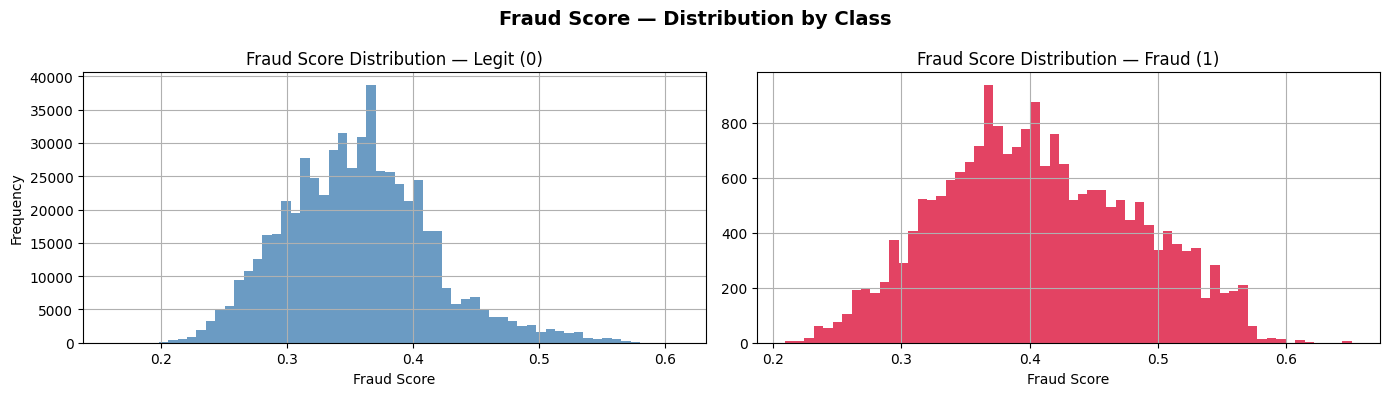

In [30]:
# PLOT — score distribution by class
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

train[train["isFraud"] == 0]["fraud_score"].hist(
    bins=60, ax=axes[0], color="steelblue", alpha=0.8
)
axes[0].set_title("Fraud Score Distribution — Legit (0)")
axes[0].set_xlabel("Fraud Score")
axes[0].set_ylabel("Frequency")

train[train["isFraud"] == 1]["fraud_score"].hist(
    bins=60, ax=axes[1], color="crimson", alpha=0.8
)
axes[1].set_title("Fraud Score Distribution — Fraud (1)")
axes[1].set_xlabel("Fraud Score")

plt.suptitle("Fraud Score — Distribution by Class", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

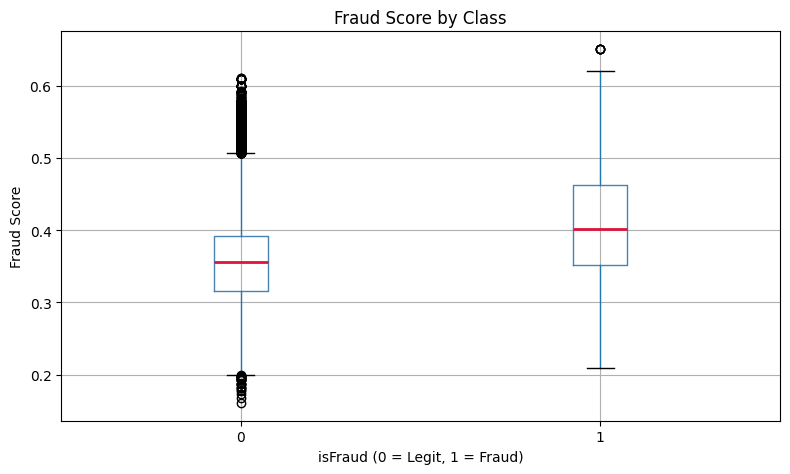

In [31]:
# PLOT — score vs isFraud (boxplot)
fig, ax = plt.subplots(figsize=(8, 5))

train.boxplot(column="fraud_score", by="isFraud", ax=ax,
              boxprops=dict(color="steelblue"),
              medianprops=dict(color="crimson", linewidth=2))

ax.set_title("Fraud Score by Class")
ax.set_xlabel("isFraud (0 = Legit, 1 = Fraud)")
ax.set_ylabel("Fraud Score")
plt.suptitle("")
plt.tight_layout()
plt.show()

In [32]:
# SCORE BUCKETS — risk tiers
train["risk_tier"] = pd.cut(
    train["fraud_score"],
    bins=[0, 0.25, 0.50, 0.75, 1.0],
    labels=["Low", "Medium", "High", "Critical"]
)

risk_summary = (
    train.groupby("risk_tier", observed=True)["isFraud"]
    .agg(["sum", "count", "mean"])
    .rename(columns={"sum": "fraud_count", "count": "total", "mean": "fraud_rate"})
)
risk_summary["fraud_rate_pct"] = (risk_summary["fraud_rate"] * 100).round(2)

print("\n--- Risk Tier Summary ---")
display(risk_summary)


--- Risk Tier Summary ---


,fraud_count,total,fraud_rate,fraud_rate_pct
risk_tier,,,,
Low,194,12092,0.016044,1.60
Medium,17737,564738,0.031407,3.14
High,2732,13710,0.199271,19.93


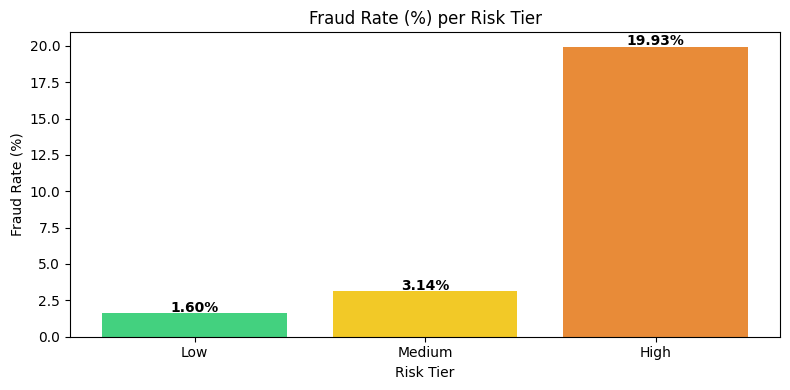

In [33]:
# PLOT — fraud rate per risk tier
fig, ax = plt.subplots(figsize=(8, 4))

colors = ["#2ecc71", "#f1c40f", "#e67e22", "#e74c3c"]
ax.bar(risk_summary.index, risk_summary["fraud_rate_pct"], color=colors, alpha=0.9)
ax.set_title("Fraud Rate (%) per Risk Tier")
ax.set_xlabel("Risk Tier")
ax.set_ylabel("Fraud Rate (%)")
for i, (idx, row) in enumerate(risk_summary.iterrows()):
    ax.text(i, row["fraud_rate_pct"] + 0.1, f'{row["fraud_rate_pct"]:.2f}%', ha="center", fontweight="bold")

plt.tight_layout()
plt.show()

# Part 4.2 - EAD Analysis fraud

In [34]:
"""
IEEE-CIS Fraud Detection — Fraud EDA Complete
==============================================
Correlation, numeric distribution by class, and missing value
analysis across all feature groups: TransactionAmt, fraud_score,
card1-3, V features, and id features.
"""

# NUMERIC FEATURE GROUPS
card_features = ["card1", "card2", "card3"]

v_features = [c for c in train.columns if c.startswith("V")]

id_features = [c for c in train.columns if c.startswith("id_") and
               train[c].dtype in [np.float32, np.float64, np.int8, np.int16, np.int32]]

base_features = ["TransactionAmt", "fraud_score"]

all_numeric_features = base_features + card_features + v_features + id_features

print(f"V features   : {len(v_features)}")
print(f"id features  : {len(id_features)}")
print(f"card features: {len(card_features)}")
print(f"Total numeric: {len(all_numeric_features)}")

V features   : 339
id features  : 23
card features: 3
Total numeric: 367



Computing correlations with isFraud...


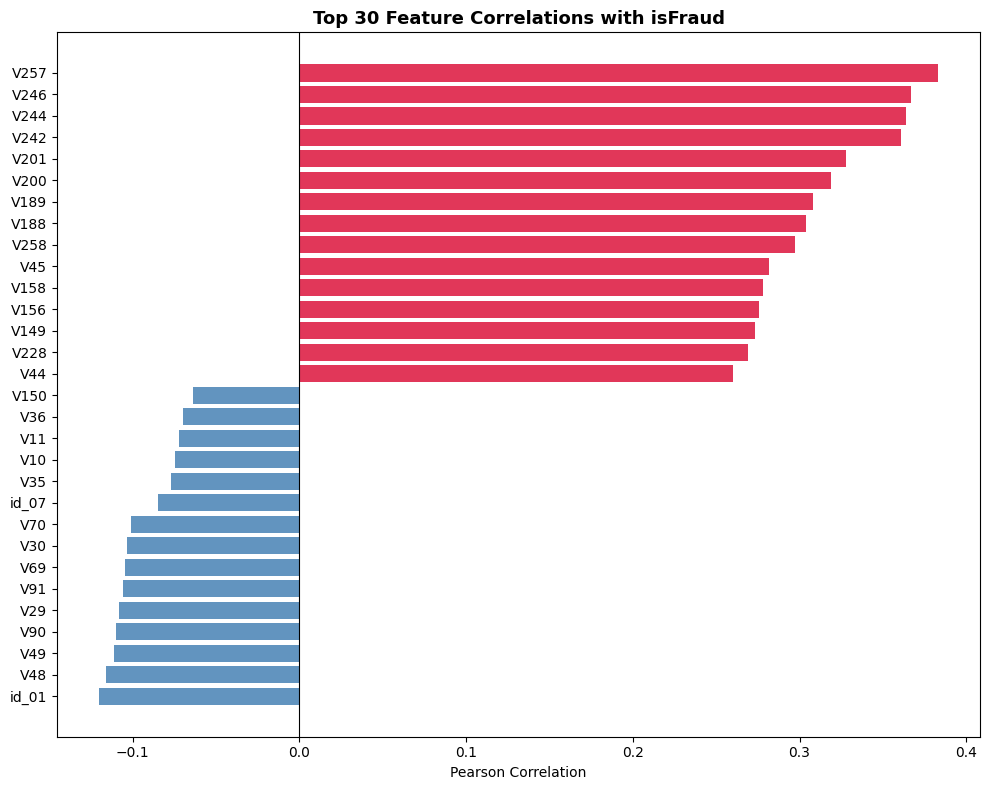

In [35]:
# CORRELATION WITH isFraud
print("\nComputing correlations with isFraud...")

corr_series = (
    train[all_numeric_features + ["isFraud"]]
    .corr()["isFraud"]
    .drop("isFraud")
    .dropna()
    .sort_values(key=abs, ascending=False)
)

top_positive = corr_series[corr_series > 0].head(15)
top_negative = corr_series[corr_series < 0].head(15)
top_corr     = pd.concat([top_positive, top_negative]).sort_values()

fig, ax = plt.subplots(figsize=(10, 8))
colors = ["crimson" if v > 0 else "steelblue" for v in top_corr.values]
ax.barh(top_corr.index, top_corr.values, color=colors, alpha=0.85)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_title("Top 30 Feature Correlations with isFraud", fontsize=13, fontweight="bold")
ax.set_xlabel("Pearson Correlation")
plt.tight_layout()
plt.show()

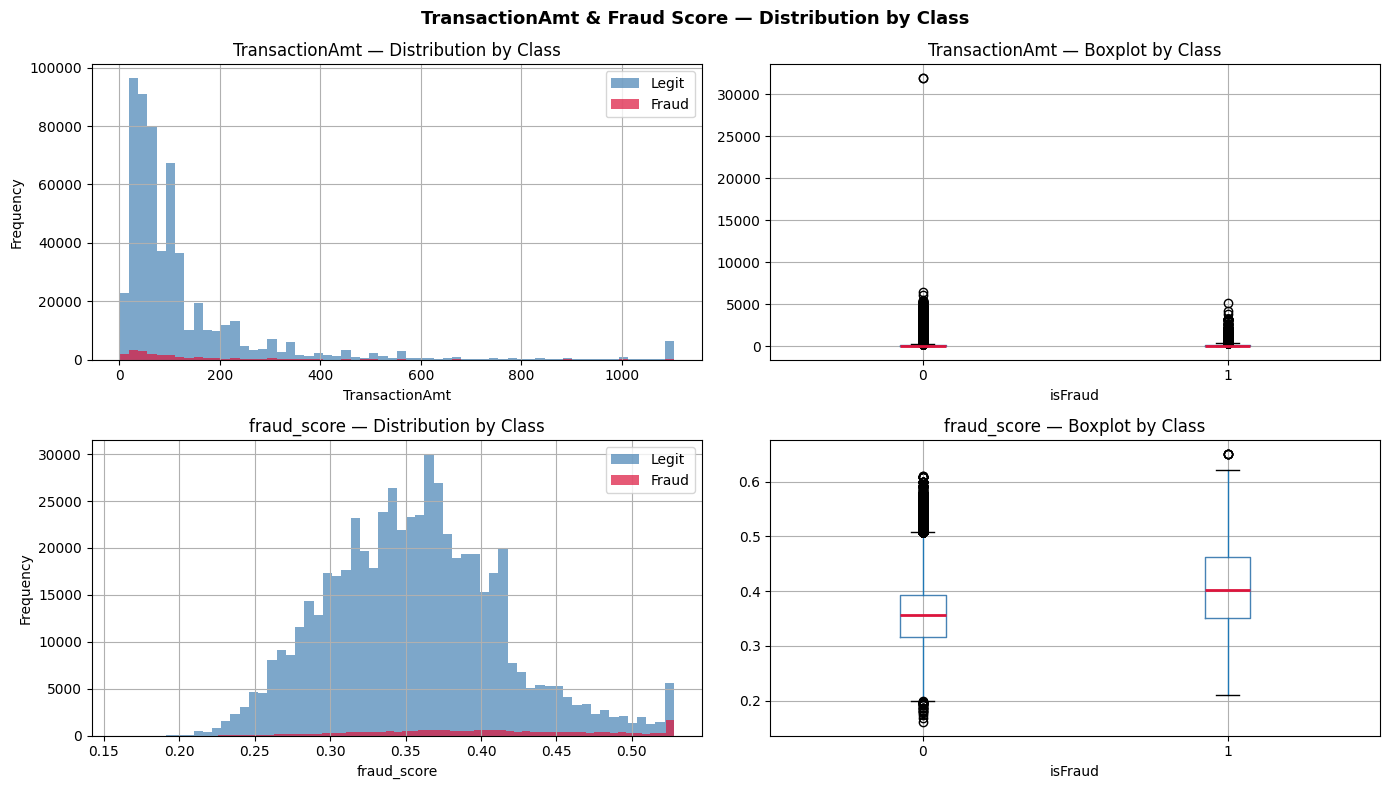

In [36]:
# DISTRIBUTION BY CLASS — TransactionAmt + fraud_score
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

for i, feat in enumerate(base_features):
    ax_hist = axes[i][0]
    ax_box  = axes[i][1]

    train[train["isFraud"] == 0][feat].clip(
        upper=train[feat].quantile(0.99)
    ).hist(bins=60, ax=ax_hist, color="steelblue", alpha=0.7, label="Legit")

    train[train["isFraud"] == 1][feat].clip(
        upper=train[feat].quantile(0.99)
    ).hist(bins=60, ax=ax_hist, color="crimson", alpha=0.7, label="Fraud")

    ax_hist.set_title(f"{feat} — Distribution by Class")
    ax_hist.set_xlabel(feat)
    ax_hist.set_ylabel("Frequency")
    ax_hist.legend()

    train.boxplot(column=feat, by="isFraud", ax=ax_box,
                  boxprops=dict(color="steelblue"),
                  medianprops=dict(color="crimson", linewidth=2))
    ax_box.set_title(f"{feat} — Boxplot by Class")
    ax_box.set_xlabel("isFraud")
    plt.sca(ax_box)
    plt.title(f"{feat} — Boxplot by Class")

plt.suptitle("TransactionAmt & Fraud Score — Distribution by Class",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

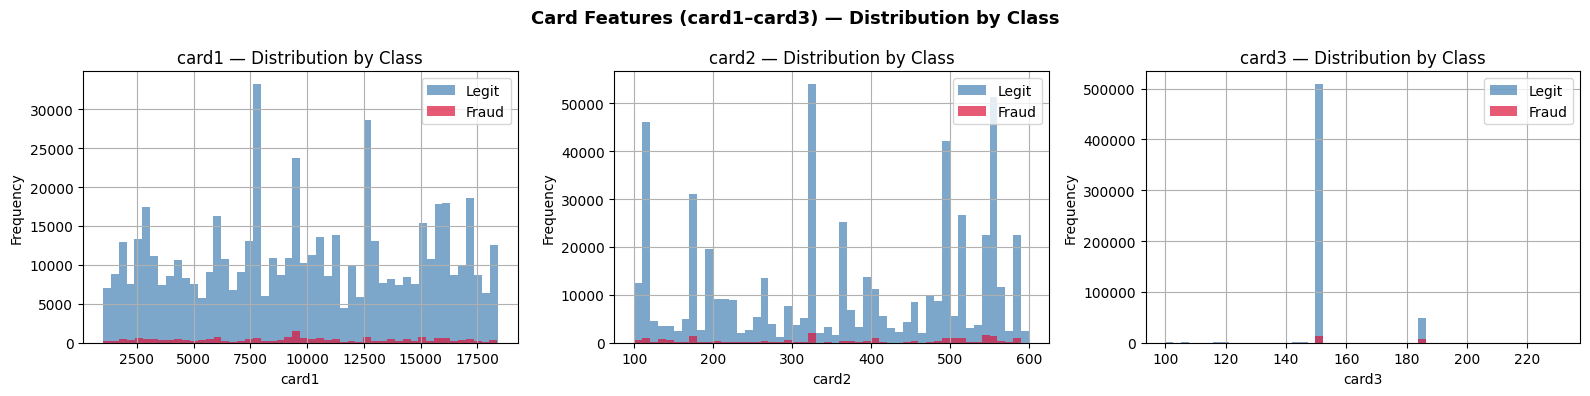

In [37]:
# DISTRIBUTION BY CLASS — card1, card2, card3
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, col in zip(axes, card_features):
    train[train["isFraud"] == 0][col].hist(
        bins=50, ax=ax, color="steelblue", alpha=0.7, label="Legit"
    )
    train[train["isFraud"] == 1][col].hist(
        bins=50, ax=ax, color="crimson", alpha=0.7, label="Fraud"
    )
    ax.set_title(f"{col} — Distribution by Class")
    ax.set_xlabel(col)
    ax.set_ylabel("Frequency")
    ax.legend()

plt.suptitle("Card Features (card1–card3) — Distribution by Class",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

In [38]:
# TOP V FEATURES — by absolute correlation
top_v = corr_series[corr_series.index.isin(v_features)].abs().nlargest(10).index.tolist()

print(f"\n--- Top 10 V features by |correlation| with isFraud ---")
display(corr_series[top_v].round(4).to_frame("correlation"))


--- Top 10 V features by |correlation| with isFraud ---


,correlation
V257,0.3831
V246,0.3669
V244,0.3641
V242,0.3606
V201,0.3280
V200,0.3188
V189,0.3082
V188,0.3036
V258,0.2972
V45,0.2818


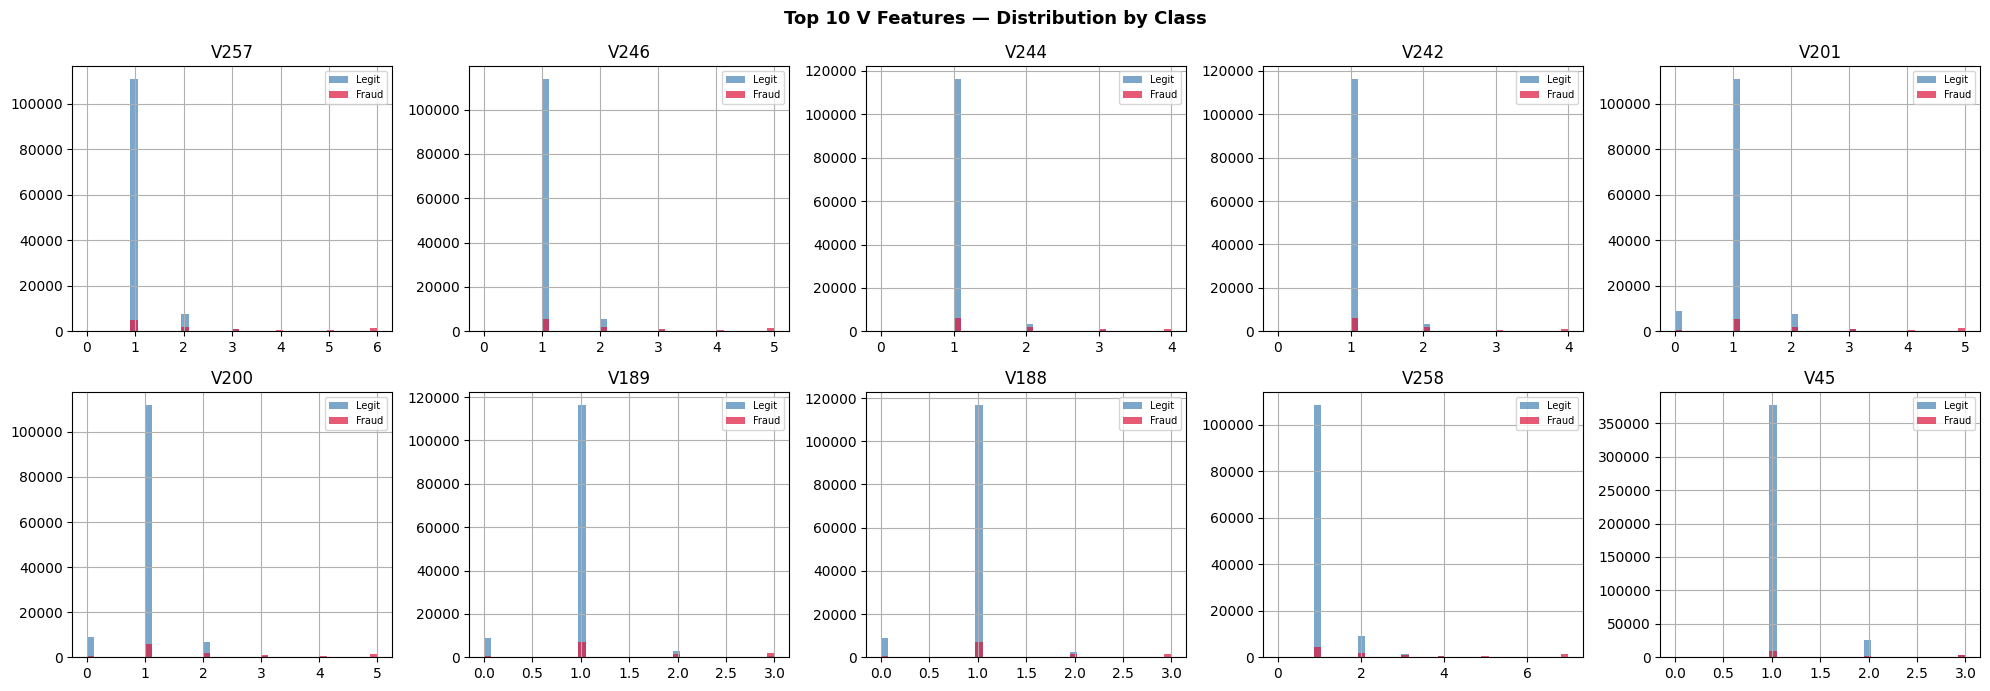

In [39]:
fig, axes = plt.subplots(2, 5, figsize=(20, 7))
axes = axes.flatten()

for i, col in enumerate(top_v):
    train[train["isFraud"] == 0][col].clip(
        upper=train[col].quantile(0.99)
    ).hist(bins=40, ax=axes[i], color="steelblue", alpha=0.7, label="Legit")

    train[train["isFraud"] == 1][col].clip(
        upper=train[col].quantile(0.99)
    ).hist(bins=40, ax=axes[i], color="crimson", alpha=0.7, label="Fraud")

    axes[i].set_title(col)
    axes[i].legend(fontsize=7)

plt.suptitle("Top 10 V Features — Distribution by Class",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

In [40]:
# TOP ID FEATURES — by absolute correlation
top_id = corr_series[corr_series.index.isin(id_features)].abs().nlargest(10).index.tolist()

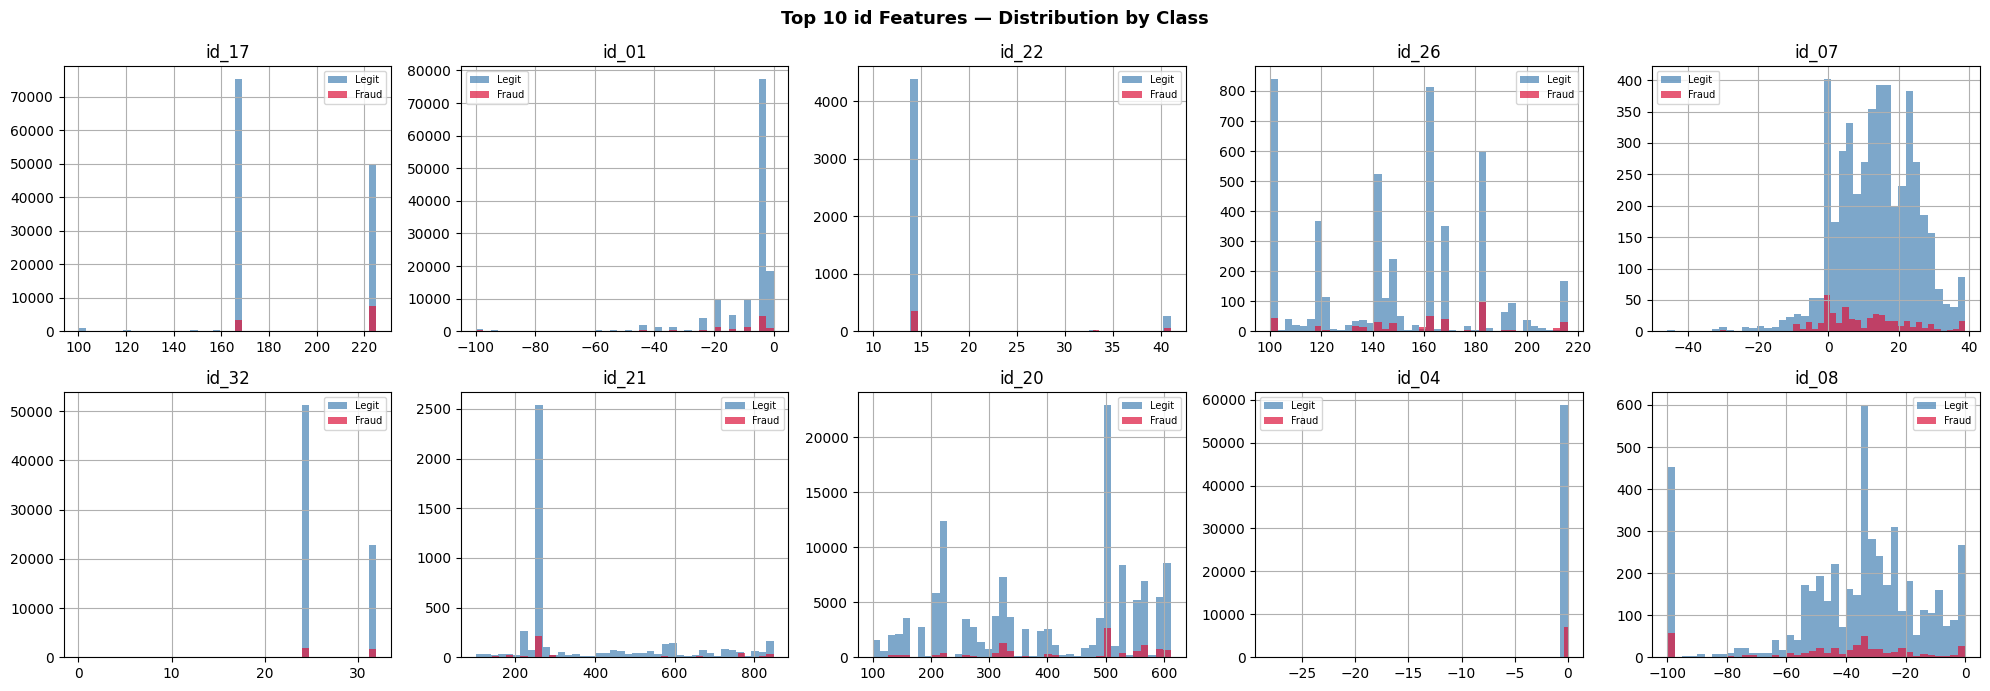

In [41]:
fig, axes = plt.subplots(2, 5, figsize=(20, 7))
axes = axes.flatten()

for i, col in enumerate(top_id):
    train[train["isFraud"] == 0][col].clip(
        upper=train[col].quantile(0.99)
    ).hist(bins=40, ax=axes[i], color="steelblue", alpha=0.7, label="Legit")

    train[train["isFraud"] == 1][col].clip(
        upper=train[col].quantile(0.99)
    ).hist(bins=40, ax=axes[i], color="crimson", alpha=0.7, label="Fraud")

    axes[i].set_title(col)
    axes[i].legend(fontsize=7)

plt.suptitle("Top 10 id Features — Distribution by Class",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

In [42]:
# MISSING VALUES BY CLASS
fraud_mask  = train["isFraud"] == 1
legit_mask  = train["isFraud"] == 0

missing_fraud = train[fraud_mask][all_numeric_features].isnull().mean() * 100
missing_legit = train[legit_mask][all_numeric_features].isnull().mean() * 100

missing_by_class = pd.DataFrame({
    "missing_legit_pct":  missing_legit,
    "missing_fraud_pct":  missing_fraud,
    "diff_pct":           (missing_fraud - missing_legit).abs()
}).sort_values("diff_pct", ascending=False)

print("\n--- Top 20 features with biggest missing rate difference by class ---")
display(missing_by_class.head(20).round(2))


--- Top 20 features with biggest missing rate difference by class ---


,missing_legit_pct,missing_fraud_pct,diff_pct
id_02,77.25,45.69,31.56
id_11,77.23,45.71,31.52
id_01,76.68,45.23,31.45
id_05,77.91,46.85,31.06
id_06,77.91,46.85,31.06
V209,77.41,46.43,30.98
V208,77.41,46.43,30.98
V210,77.41,46.43,30.98
V197,77.41,46.43,30.98
V198,77.41,46.43,30.98


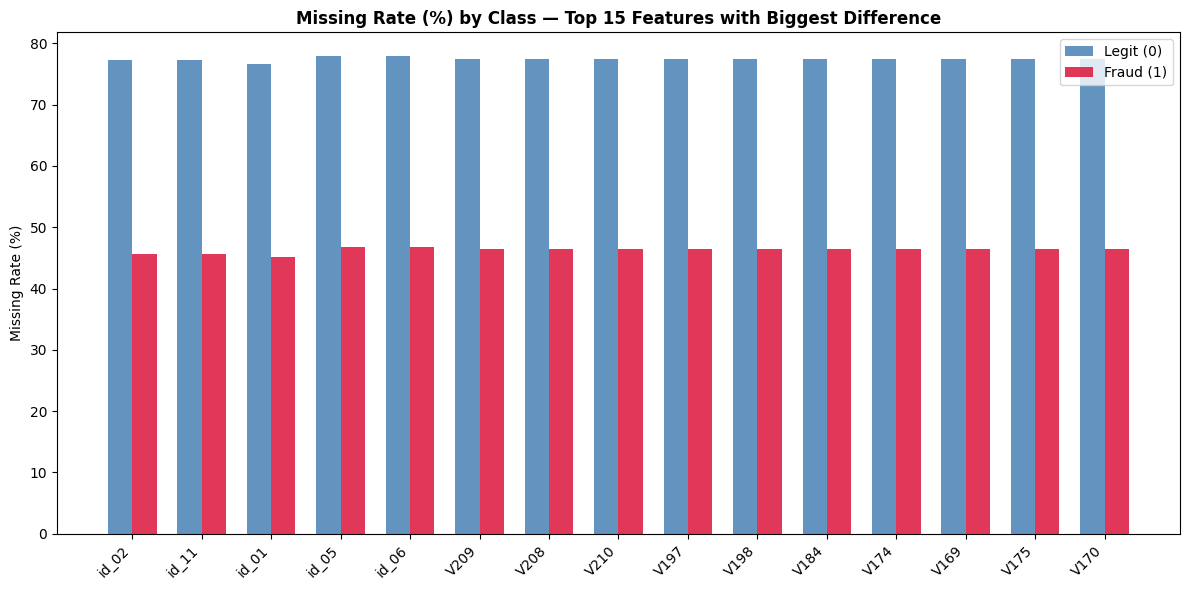

In [43]:
top_missing_diff = missing_by_class.head(15)

fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(top_missing_diff))
width = 0.35

ax.bar(x - width/2, top_missing_diff["missing_legit_pct"],
       width, label="Legit (0)", color="steelblue", alpha=0.85)
ax.bar(x + width/2, top_missing_diff["missing_fraud_pct"],
       width, label="Fraud (1)", color="crimson", alpha=0.85)

ax.set_title("Missing Rate (%) by Class — Top 15 Features with Biggest Difference",
             fontsize=12, fontweight="bold")
ax.set_ylabel("Missing Rate (%)")
ax.set_xticks(x)
ax.set_xticklabels(top_missing_diff.index, rotation=45, ha="right")
ax.legend()
plt.tight_layout()
plt.show()

In [44]:
# STATISTICAL TEST — Mann-Whitney U per top correlated feature

top_test_features = corr_series.abs().nlargest(10).index.tolist()
mw_results = []

for col in top_test_features:
    legit_vals = train[legit_mask][col].dropna()
    fraud_vals = train[fraud_mask][col].dropna()
    stat, p    = stats.mannwhitneyu(legit_vals, fraud_vals, alternative="two-sided")
    mw_results.append({
        "feature":     col,
        "correlation": round(corr_series[col], 4),
        "U_statistic": round(stat, 2),
        "p_value":     round(p, 6),
        "significant": p < 0.05
    })

display(pd.DataFrame(mw_results))

,feature,correlation,U_statistic,p_value,significant
0,V257,0.3831,3.334352e+08,0.0,True
1,V246,0.3669,3.589754e+08,0.0,True
2,V244,0.3641,3.930669e+08,0.0,True
3,V242,0.3606,3.986525e+08,0.0,True
4,V201,0.3280,4.324375e+08,0.0,True
5,V200,0.3188,4.500437e+08,0.0,True
6,V189,0.3082,4.926070e+08,0.0,True
7,V188,0.3036,5.110751e+08,0.0,True
8,V258,0.2972,3.121399e+08,0.0,True
9,V45,0.2818,2.141934e+09,0.0,True


# Part 5 - SMOTE

In [45]:
# ROBUST SCALER — TransactionAmt e TransactionDT
robust_scaler = RobustScaler()

train["TransactionAmt"] = robust_scaler.fit_transform(train["TransactionAmt"].values.reshape(-1, 1))
test["TransactionAmt"]  = robust_scaler.transform(test["TransactionAmt"].values.reshape(-1, 1))

train["TransactionDT"] = robust_scaler.fit_transform(train["TransactionDT"].values.reshape(-1, 1))
test["TransactionDT"]  = robust_scaler.transform(test["TransactionDT"].values.reshape(-1, 1))

print("RobustScaler aplicado em TransactionAmt e TransactionDT.")
print(train[["TransactionAmt", "TransactionDT"]].describe().round(4))

robust_scaler

RobustScaler aplicado em TransactionAmt e TransactionDT.
       TransactionAmt  TransactionDT
count     590540.0000    590540.0000
mean           0.8112         0.0080
std            2.9268         0.5617
min           -0.8389        -0.8784
25%           -0.3116        -0.5206
50%            0.0000         0.0000
75%            0.6884         0.4794
max          390.1691         1.0347


RobustScaler()

In [46]:
# FEATURE SELECTION — numeric only, drop target and helpers
drop_cols = ["isFraud", "TransactionID", "hour", "day", "fraud_score", "risk_tier"]
drop_cols = [c for c in drop_cols if c in train.columns]

num_cols = train.drop(columns=drop_cols).select_dtypes(include=[np.number]).columns.tolist()

X = train[num_cols].fillna(-999)
Y = train["isFraud"]

print(f"Features usadas: {X.shape[1]}")
print(f"Amostras totais: {X.shape[0]}")
print(f"\nDistribuição original:")
print(Y.value_counts())
print(f"Fraud rate: {Y.mean() * 100:.2f}%")

Features usadas: 401
Amostras totais: 590540

Distribuição original:
isFraud
0    569877
1     20663
Name: count, dtype: int64
Fraud rate: 3.50%


In [47]:
# STRATIFIED KFOLD SETUP
strat_kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for idx_train, idx_test in strat_kfold.split(X, Y):
    X_train, X_test = X.iloc[idx_train], X.iloc[idx_test]
    Y_train, Y_test = Y.iloc[idx_train], Y.iloc[idx_test]

X_train = X_train.values
X_test  = X_test.values
Y_train = Y_train.values
Y_test  = Y_test.values

print(f"\nTrain distribution — 0: {(Y_train == 0).sum()} | 1: {(Y_train == 1).sum()}")
print(f"Test  distribution — 0: {(Y_test  == 0).sum()} | 1: {(Y_test  == 1).sum()}")


Train distribution — 0: 455902 | 1: 16530
Test  distribution — 0: 113975 | 1: 4133


In [48]:
# RANDOM UNDERSAMPLING
rus = RandomUnderSampler(random_state=42)
X_under, Y_under = rus.fit_resample(X_train, Y_train)

contagem_under = Counter(Y_under)
print(f"\nRandom Undersampling: {contagem_under}")


Random Undersampling: Counter({np.int8(0): 16530, np.int8(1): 16530})


In [49]:
# SMOTE OVERSAMPLING
smote = SMOTE(sampling_strategy="minority", random_state=42)
X_smote, Y_smote = smote.fit_resample(X_train, Y_train)

contagem_smote = Counter(Y_smote)
print(f"SMOTE: {contagem_smote}")

SMOTE: Counter({np.int8(0): 455902, np.int8(1): 455902})


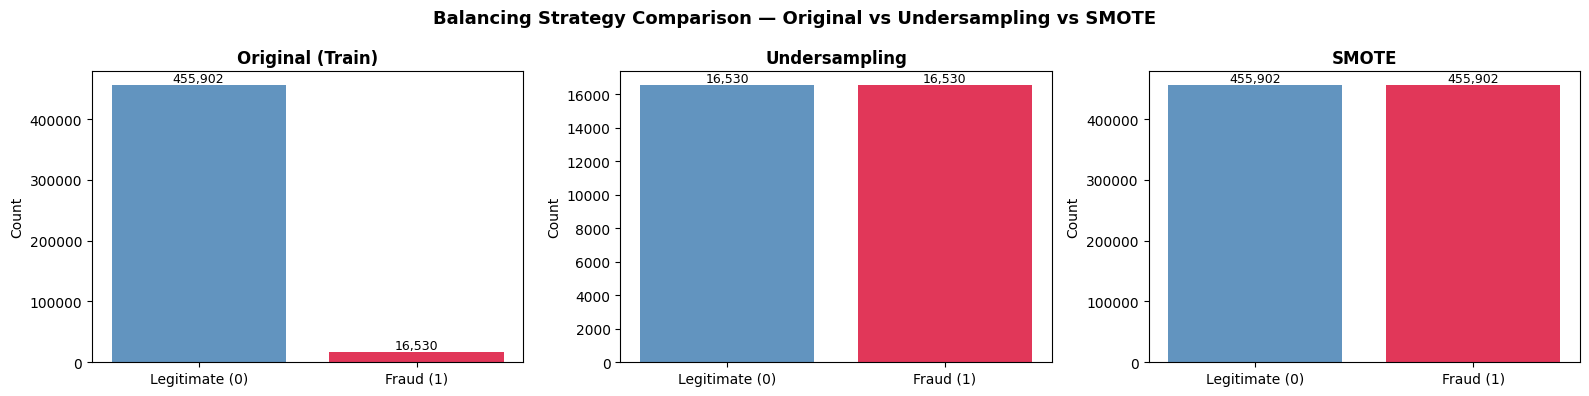

In [50]:
# PLOT — balancing strategy distribution comparison
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

datasets = {
    "Original (Train)": Y_train,
    "Undersampling":    Y_under,
    "SMOTE":            Y_smote,
}

for ax, (title, y) in zip(axes, datasets.items()):
    count = Counter(y)
    ax.bar(
        ["Legitimate (0)", "Fraud (1)"],
        [count[0], count[1]],
        color=["steelblue", "crimson"],
        alpha=0.85
    )
    ax.set_title(title, fontsize=12, fontweight="bold")
    ax.set_ylabel("Count")
    for i, v in enumerate([count[0], count[1]]):
        ax.text(i, v + max(count.values()) * 0.01, f"{v:,}", ha="center", fontsize=9)

plt.suptitle("Balancing Strategy Comparison — Original vs Undersampling vs SMOTE",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

In [51]:
# RANDOM UNDERSAMPLING
rus             = RandomUnderSampler(random_state=42)
X_under, Y_under = rus.fit_resample(X_train, Y_train)

count_under = Counter(Y_under)
print(f"\nRandom Undersampling: {count_under}")

# SMOTE OVERSAMPLING
smote            = SMOTE(sampling_strategy="minority", random_state=42)
X_smote, Y_smote = smote.fit_resample(X_train, Y_train)

count_smote = Counter(Y_smote)
print(f"SMOTE              : {count_smote}")


Random Undersampling: Counter({np.int8(0): 16530, np.int8(1): 16530})
SMOTE              : Counter({np.int8(0): 455902, np.int8(1): 455902})


In [52]:
# SUMMARY TABLE
summary = pd.DataFrame({
    "Strategy":     ["Original", "Undersampling", "SMOTE"],
    "Total":        [len(Y_train), len(Y_under), len(Y_smote)],
    "Legitimate (0)": [(Y_train == 0).sum(), count_under[0], count_smote[0]],
    "Fraud (1)":    [(Y_train == 1).sum(), count_under[1], count_smote[1]],
    "Fraud Rate %": [
        round((Y_train == 1).mean() * 100, 2),
        round((Y_under == 1).mean() * 100, 2),
        round((Y_smote == 1).mean() * 100, 2),
    ]
})

print("\n--- Balancing Summary ---")
display(summary)

# VARIABLES EXPORTED TO PART 3
print("\nVariables exported to Part 3:")
print("  X_train, Y_train — original stratified base")
print("  X_under, Y_under — Random Undersampling")
print("  X_smote, Y_smote — SMOTE")
print("  X_test,  Y_test  — fixed holdout for final evaluation")


--- Balancing Summary ---


,Strategy,Total,Legitimate (0),Fraud (1),Fraud Rate %
0,Original,472432,455902,16530,3.5
1,Undersampling,33060,16530,16530,50.0
2,SMOTE,911804,455902,455902,50.0



Variables exported to Part 3:
  X_train, Y_train — original stratified base
  X_under, Y_under — Random Undersampling
  X_smote, Y_smote — SMOTE
  X_test,  Y_test  — fixed holdout for final evaluation


# **Part 6 - Dimensionality Reduction Models (PCA SVD t_SNE)**

In [53]:
"""
IEEE-CIS Fraud Detection — Dimensionality Reduction (Part 3.5)
==============================================================
Applies PCA, t-SNE and TruncatedSVD on the balanced sample (Undersampling)
to visualize class separation between Legitimate and Fraud transactions.
"""

# SAMPLE FOR VISUALIZATION — uses undersampling (smaller, more viable for t-SNE)
X_vis = X_under
Y_vis = Y_under

print(f"Samples for visualization: {X_vis.shape[0]}")
print(f"Features                 : {X_vis.shape[1]}")
print(f"Distribution — 0: {(Y_vis == 0).sum()} | 1: {(Y_vis == 1).sum()}")

# PCA
print("\nApplying PCA...")
X_pca = PCA(n_components=2, random_state=42).fit_transform(X_vis)

# TRUNCATED SVD
print("Applying TruncatedSVD...")
X_svd = TruncatedSVD(n_components=2, algorithm="randomized", random_state=42).fit_transform(X_vis)

# t-SNE — slower, runs last
print("Applying t-SNE (this may take a few minutes)...")
X_tsne = TSNE(n_components=2, random_state=42, perplexity=30,
              n_iter=1000, learning_rate="auto", init="pca").fit_transform(X_vis)

print("Dimensionality reduction complete.")

Samples for visualization: 33060
Features                 : 401
Distribution — 0: 16530 | 1: 16530

Applying PCA...
Applying TruncatedSVD...
Applying t-SNE (this may take a few minutes)...
Dimensionality reduction complete.


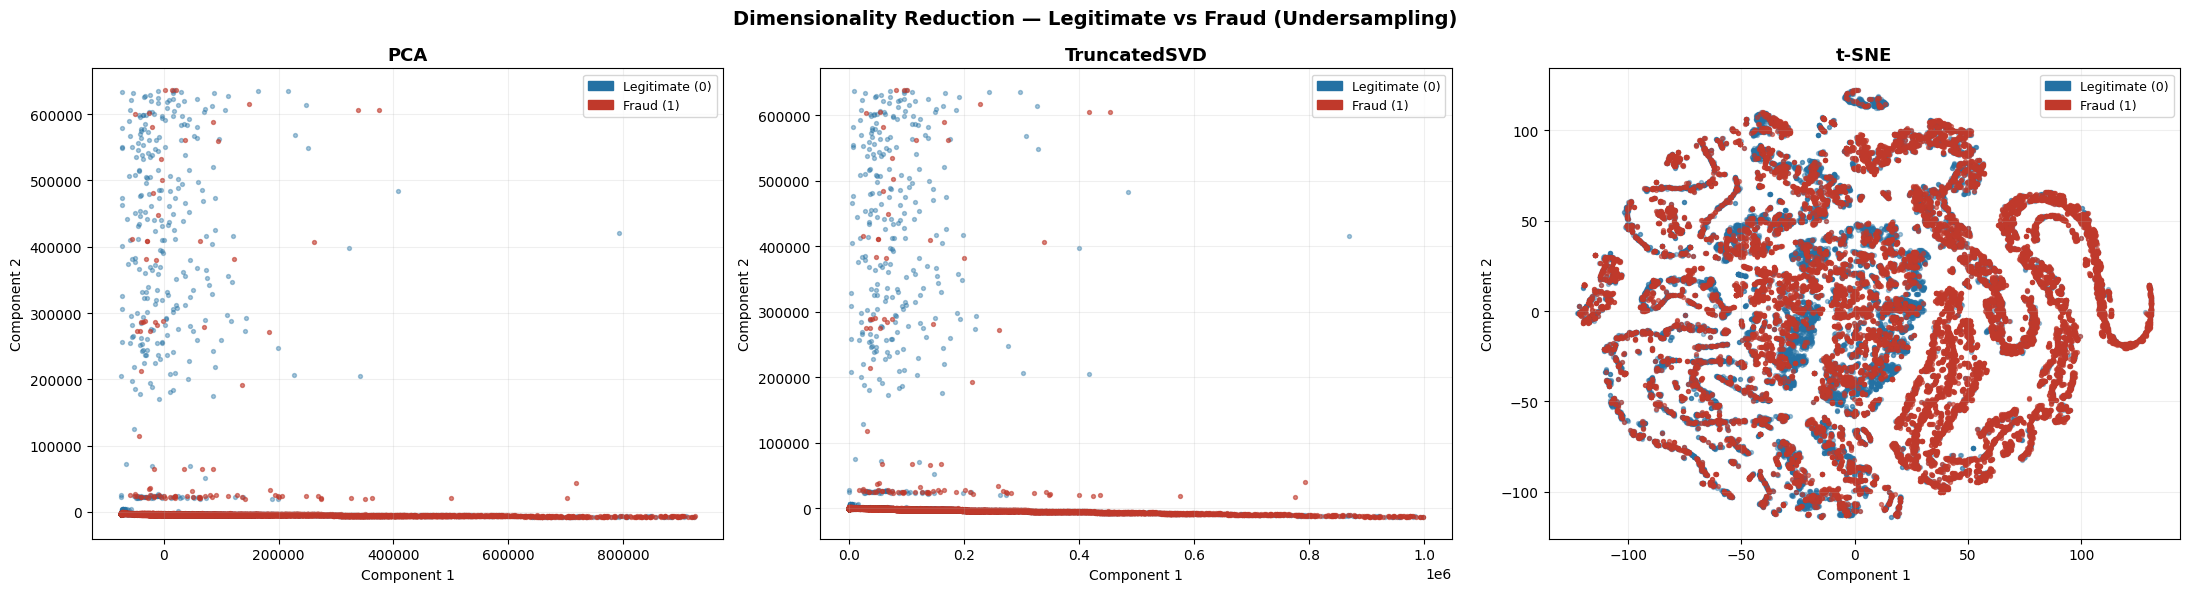

In [54]:
# LEGEND
patch_legitimate = mpatches.Patch(color="#2471A3", label="Legitimate (0)")
patch_fraud = mpatches.Patch(color="#C0392B", label="Fraud (1)")

# PLOT — PCA, SVD, t-SNE side by side
fig, axes = plt.subplots(1, 3, figsize=(22, 6))

reductions = {"PCA": X_pca,
              "TruncatedSVD": X_svd,
              "t-SNE": X_tsne,
             }

for ax, (title, X_red) in zip(axes, reductions.items()):
    ax.scatter(X_red[Y_vis == 0, 0], X_red[Y_vis == 0, 1], c="#2471A3", alpha=0.4, s=8, label="Legitimate (0)")
    ax.scatter(X_red[Y_vis == 1, 0], X_red[Y_vis == 1, 1], c="#C0392B", alpha=0.6, s=8, label="Fraud (1)")
    ax.set_title(title, fontsize=13, fontweight="bold")
    ax.set_xlabel("Component 1")
    ax.set_ylabel("Component 2")
    ax.legend(handles=[patch_legitimate, patch_fraud], fontsize=9)
    ax.grid(True, alpha=0.2)

plt.suptitle("Dimensionality Reduction — Legitimate vs Fraud (Undersampling)",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

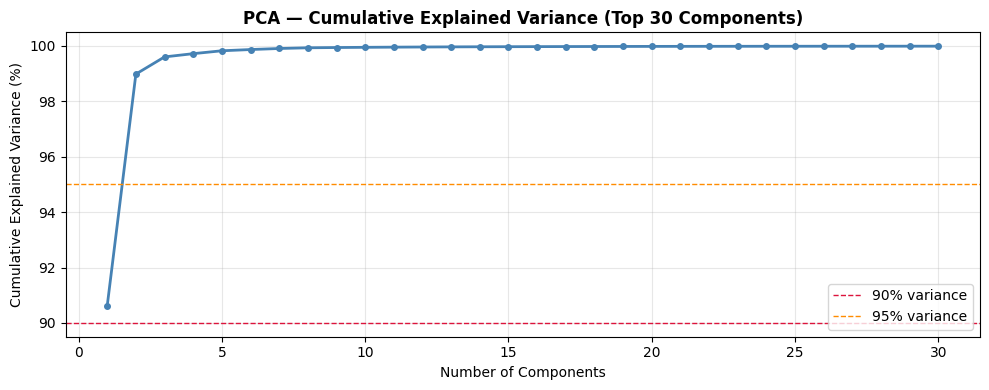

Components needed for 80% variance: 1
Components needed for 90% variance: 1
Components needed for 95% variance: 2
Components needed for 99% variance: 3


In [55]:
# PLOT — PCA explained variance
pca_full = PCA(n_components=30, random_state=42).fit(X_vis)
explained_var = np.cumsum(pca_full.explained_variance_ratio_) * 100

fig, ax = plt.subplots(figsize=(10, 4))

ax.plot(range(1, len(explained_var) + 1), explained_var, marker="o", color="steelblue", linewidth=2, markersize=4)
ax.axhline(90, color="crimson",    linestyle="--", linewidth=1, label="90% variance")
ax.axhline(95, color="darkorange", linestyle="--", linewidth=1, label="95% variance")
ax.set_title("PCA — Cumulative Explained Variance (Top 30 Components)",fontsize=12, fontweight="bold")
ax.set_xlabel("Number of Components")
ax.set_ylabel("Cumulative Explained Variance (%)")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# COMPONENTS REQUIRED PER VARIANCE THRESHOLD
for threshold in [80, 90, 95, 99]:
    n_comp = np.argmax(explained_var >= threshold) + 1
    print(f"Components needed for {threshold}% variance: {n_comp}")

In [56]:
# VARIANCE THRESHOLD
VARIANCE_THRESHOLD = 0.90

# AUTOMATIC SELECTION — PCA vs TruncatedSVD by explained variance
def select_reducer(X_tr: np.ndarray, threshold: float) -> tuple:
    """
    Compares PCA and TruncatedSVD and selects the one that reaches
    the variance threshold with fewer components.

    Parameters
    ----------
    X_tr : np.ndarray
        Training data for fitting the reducer.
    threshold : float
        Minimum cumulative explained variance ratio (e.g. 0.90).

    Returns
    -------
    tuple
        (reducer_name, fitted_reducer, n_components)
    """
    results = {}

    for name, ReducerClass in [("PCA", PCA), ("TruncatedSVD", TruncatedSVD)]:
        reducer_tmp = ReducerClass(n_components=min(X_tr.shape[1], 200), random_state=42)
        reducer_tmp.fit(X_tr)
        cum_var     = np.cumsum(reducer_tmp.explained_variance_ratio_)
        n_comp      = int(np.argmax(cum_var >= threshold) + 1)
        results[name] = {"n_comp": n_comp, "cum_var": cum_var}
        print(f"{name}: {n_comp} components for {threshold * 100:.0f}% variance")

    best_name = min(results, key=lambda k: results[k]["n_comp"])
    best_info = results[best_name]

    print(f"\nBest reducer: {best_name} ({best_info['n_comp']} components)")

    ReducerFinal  = PCA if best_name == "PCA" else TruncatedSVD
    reducer_final = ReducerFinal(n_components=best_info["n_comp"], random_state=42)

    return best_name, reducer_final, best_info["n_comp"]

# FIT REDUCER — fit on undersampling, transform all sets
print("Selecting best reducer based on X_under...")
reducer_name, reducer, n_components = select_reducer(X_under, VARIANCE_THRESHOLD)

reducer.fit(X_under)

X_under_red = reducer.transform(X_under)
X_smote_red = reducer.transform(X_smote)
X_test_red  = reducer.transform(X_test)

print(f"\nShapes after reduction:")
print(f"  X_under_red : {X_under_red.shape}")
print(f"  X_smote_red : {X_smote_red.shape}")
print(f"  X_test_red  : {X_test_red.shape}")

Selecting best reducer based on X_under...
PCA: 1 components for 90% variance
TruncatedSVD: 1 components for 90% variance

Best reducer: PCA (1 components)

Shapes after reduction:
  X_under_red : (33060, 1)
  X_smote_red : (911804, 1)
  X_test_red  : (118108, 1)


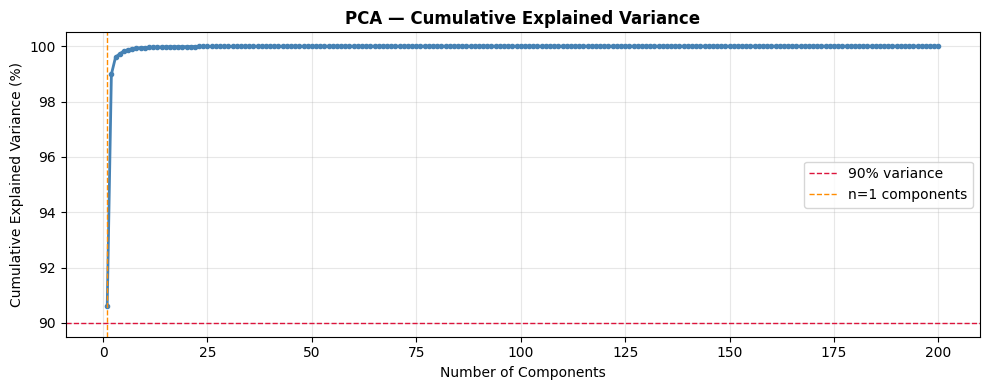

In [57]:
# PLOT — cumulative explained variance
reducer_plot = (PCA if reducer_name == "PCA" else TruncatedSVD)(
    n_components=min(X_under.shape[1], 200), random_state=42
)
reducer_plot.fit(X_under)
cum_var_plot = np.cumsum(reducer_plot.explained_variance_ratio_) * 100

fig, ax = plt.subplots(figsize=(10, 4))

ax.plot(range(1, len(cum_var_plot) + 1), cum_var_plot,
        color="steelblue", linewidth=2, marker="o", markersize=3)
ax.axhline(90, color="crimson", linestyle="--", linewidth=1, label="90% variance")
ax.axvline(n_components, color="darkorange", linestyle="--",
           linewidth=1, label=f"n={n_components} components")
ax.set_title(f"{reducer_name} — Cumulative Explained Variance",
             fontsize=12, fontweight="bold")
ax.set_xlabel("Number of Components")
ax.set_ylabel("Cumulative Explained Variance (%)")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Part 7 - Models Machine learning

In [58]:
"""
IEEE-CIS Fraud Detection — 8 Model Pipeline (Part 3)
=====================================================
Trains 8 models in a loop with Undersampling and SMOTE.
Evaluates AUC-ROC, F1, Precision, Recall and Accuracy.
Generates ROC curve, confusion matrix and final ranking.
"""

# 8 MODELS DEFINITION
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42, n_jobs=-1),
    "KNN":                 KNeighborsClassifier(n_jobs=-1),
    "Decision Tree":       DecisionTreeClassifier(random_state=42),
    "Random Forest":       RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    "Gradient Boosting":   GradientBoostingClassifier(n_estimators=100, random_state=42),
    "XGBoost":             XGBClassifier(n_estimators=100, random_state=42,
                                         eval_metric="auc", verbosity=0, n_jobs=-1),
    "LightGBM":            LGBMClassifier(n_estimators=100, random_state=42,
                                          verbosity=-1, n_jobs=-1),
    "CatBoost":            CatBoostClassifier(iterations=100, random_state=42, verbose=0),
}

# EVALUATION FUNCTION
def evaluate_pipeline(models: dict, X_tr: np.ndarray, Y_tr: np.ndarray,
                      X_te: np.ndarray, Y_te: np.ndarray,
                      strategy: str) -> pd.DataFrame:
    """
    Trains and evaluates 8 models on dimensionality-reduced data.

    Parameters
    ----------
    models : dict
        Dictionary of model name to estimator.
    X_tr : np.ndarray
        Reduced training features.
    Y_tr : np.ndarray
        Training labels.
    X_te : np.ndarray
        Reduced test features.
    Y_te : np.ndarray
        Test labels.
    strategy : str
        Balancing strategy label.

    Returns
    -------
    pd.DataFrame
        Metrics DataFrame sorted by AUC-ROC descending.
    """
    results = []

    for name, model in models.items():
        print(f"  [{strategy}] Training: {name}...")
        model.fit(X_tr, Y_tr)

        Y_pred      = model.predict(X_te)
        Y_pred_prob = (
            model.predict_proba(X_te)[:, 1]
            if hasattr(model, "predict_proba")
            else model.decision_function(X_te)
        )

        results.append({
            "Model":     name,
            "Strategy":  strategy,
            "Reducer":   reducer_name,
            "N_Comp":    n_components,
            "AUC-ROC":   round(roc_auc_score(Y_te, Y_pred_prob), 4),
            "F1":        round(f1_score(Y_te, Y_pred), 4),
            "Precision": round(precision_score(Y_te, Y_pred), 4),
            "Recall":    round(recall_score(Y_te, Y_pred), 4),
            "Accuracy":  round(accuracy_score(Y_te, Y_pred), 4),
        })

    return pd.DataFrame(results).sort_values("AUC-ROC", ascending=False)

# PIPELINE — UNDERSAMPLING + REDUCER
print("\n" + "=" * 60)
print(f"STRATEGY: Undersampling + {reducer_name}")
print("=" * 60)
df_under_red = evaluate_pipeline(models, X_under_red, Y_under, X_test_red, Y_test, "Undersampling")

# PIPELINE — SMOTE + REDUCER
print("\n" + "=" * 60)
print(f"STRATEGY: SMOTE + {reducer_name}")
print("=" * 60)
df_smote_red = evaluate_pipeline(models, X_smote_red, Y_smote, X_test_red, Y_test, "SMOTE")

# FINAL RANKING
df_final = pd.concat([df_under_red, df_smote_red], ignore_index=True)
df_final = df_final.sort_values("AUC-ROC", ascending=False).reset_index(drop=True)

print("\n--- Final Ranking — 8 Models + Dimensionality Reduction ---")
display(df_final)


STRATEGY: Undersampling + PCA
  [Undersampling] Training: Logistic Regression...
  [Undersampling] Training: KNN...
  [Undersampling] Training: Decision Tree...
  [Undersampling] Training: Random Forest...
  [Undersampling] Training: Gradient Boosting...
  [Undersampling] Training: XGBoost...
  [Undersampling] Training: LightGBM...
  [Undersampling] Training: CatBoost...

STRATEGY: SMOTE + PCA
  [SMOTE] Training: Logistic Regression...
  [SMOTE] Training: KNN...
  [SMOTE] Training: Decision Tree...
  [SMOTE] Training: Random Forest...
  [SMOTE] Training: Gradient Boosting...
  [SMOTE] Training: XGBoost...
  [SMOTE] Training: LightGBM...
  [SMOTE] Training: CatBoost...

--- Final Ranking — 8 Models + Dimensionality Reduction ---


,Model,Strategy,Reducer,N_Comp,AUC-ROC,F1,Precision,Recall,Accuracy
0,Gradient Boosting,SMOTE,PCA,1,0.6923,0.1342,0.0754,0.6105,0.7244
1,Gradient Boosting,Undersampling,PCA,1,0.6913,0.1311,0.0734,0.6124,0.7160
2,LightGBM,SMOTE,PCA,1,0.6908,0.1347,0.0758,0.6042,0.7283
3,CatBoost,SMOTE,PCA,1,0.6894,0.1339,0.0752,0.6059,0.7257
4,XGBoost,SMOTE,PCA,1,0.6892,0.1340,0.0753,0.6056,0.7261
5,CatBoost,Undersampling,PCA,1,0.6873,0.1335,0.0749,0.6109,0.7224
6,XGBoost,Undersampling,PCA,1,0.6871,0.1355,0.0764,0.5957,0.7339
7,LightGBM,Undersampling,PCA,1,0.6853,0.1329,0.0747,0.6037,0.7244
8,Logistic Regression,SMOTE,PCA,1,0.6532,0.1416,0.0844,0.4387,0.8139
9,Logistic Regression,Undersampling,PCA,1,0.6532,0.1414,0.0843,0.4389,0.8136


LEARNING CURVES: SMOTE + PCA
  Computing learning curve: Logistic Regression...
  Computing learning curve: KNN...
  Computing learning curve: Decision Tree...
  Computing learning curve: Random Forest...
  Computing learning curve: Gradient Boosting...
  Computing learning curve: XGBoost...
  Computing learning curve: LightGBM...


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/ut

  Computing learning curve: CatBoost...


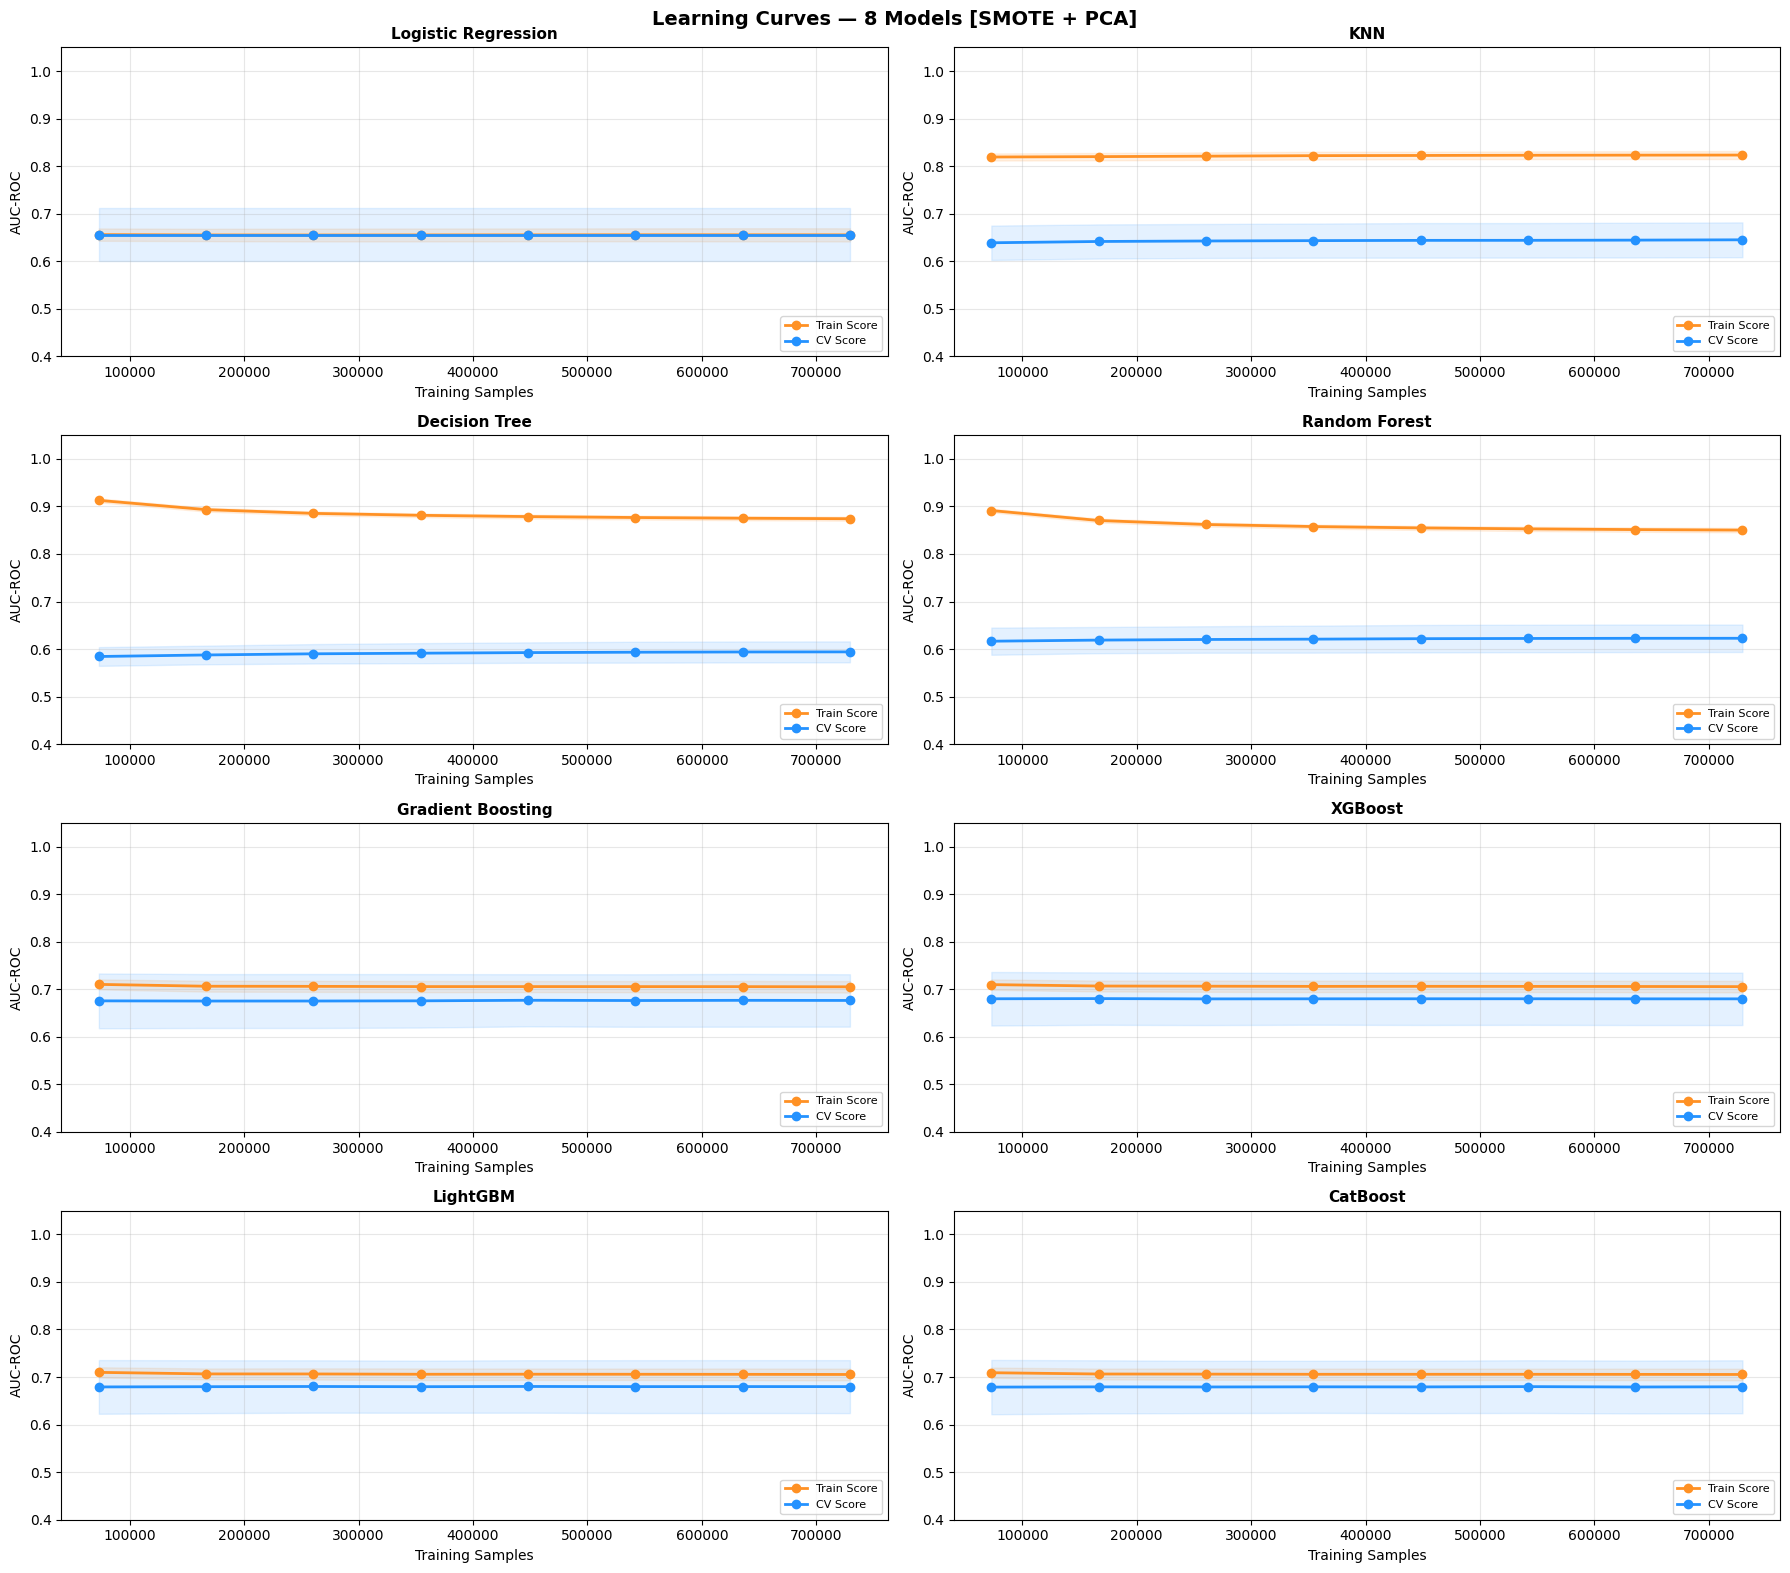


--- Learning Curve Summary [SMOTE] ---


,Model,Strategy,Train AUC (end),CV AUC (end),Gap,Diagnosis
6,LightGBM,SMOTE,0.7054,0.6799,0.0255,Good Fit
5,XGBoost,SMOTE,0.7056,0.6799,0.0257,Good Fit
7,CatBoost,SMOTE,0.7054,0.6795,0.0259,Good Fit
4,Gradient Boosting,SMOTE,0.7052,0.6765,0.0287,Good Fit
0,Logistic Regression,SMOTE,0.6557,0.6557,-0.0001,Good Fit
1,KNN,SMOTE,0.8235,0.6453,0.1782,Overfitting
3,Random Forest,SMOTE,0.8502,0.6227,0.2275,Overfitting
2,Decision Tree,SMOTE,0.8741,0.5942,0.2800,Overfitting



LEARNING CURVES: Undersampling + PCA
  Computing learning curve: Logistic Regression...
  Computing learning curve: KNN...
  Computing learning curve: Decision Tree...
  Computing learning curve: Random Forest...
  Computing learning curve: Gradient Boosting...
  Computing learning curve: XGBoost...
  Computing learning curve: LightGBM...


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/ut

  Computing learning curve: CatBoost...


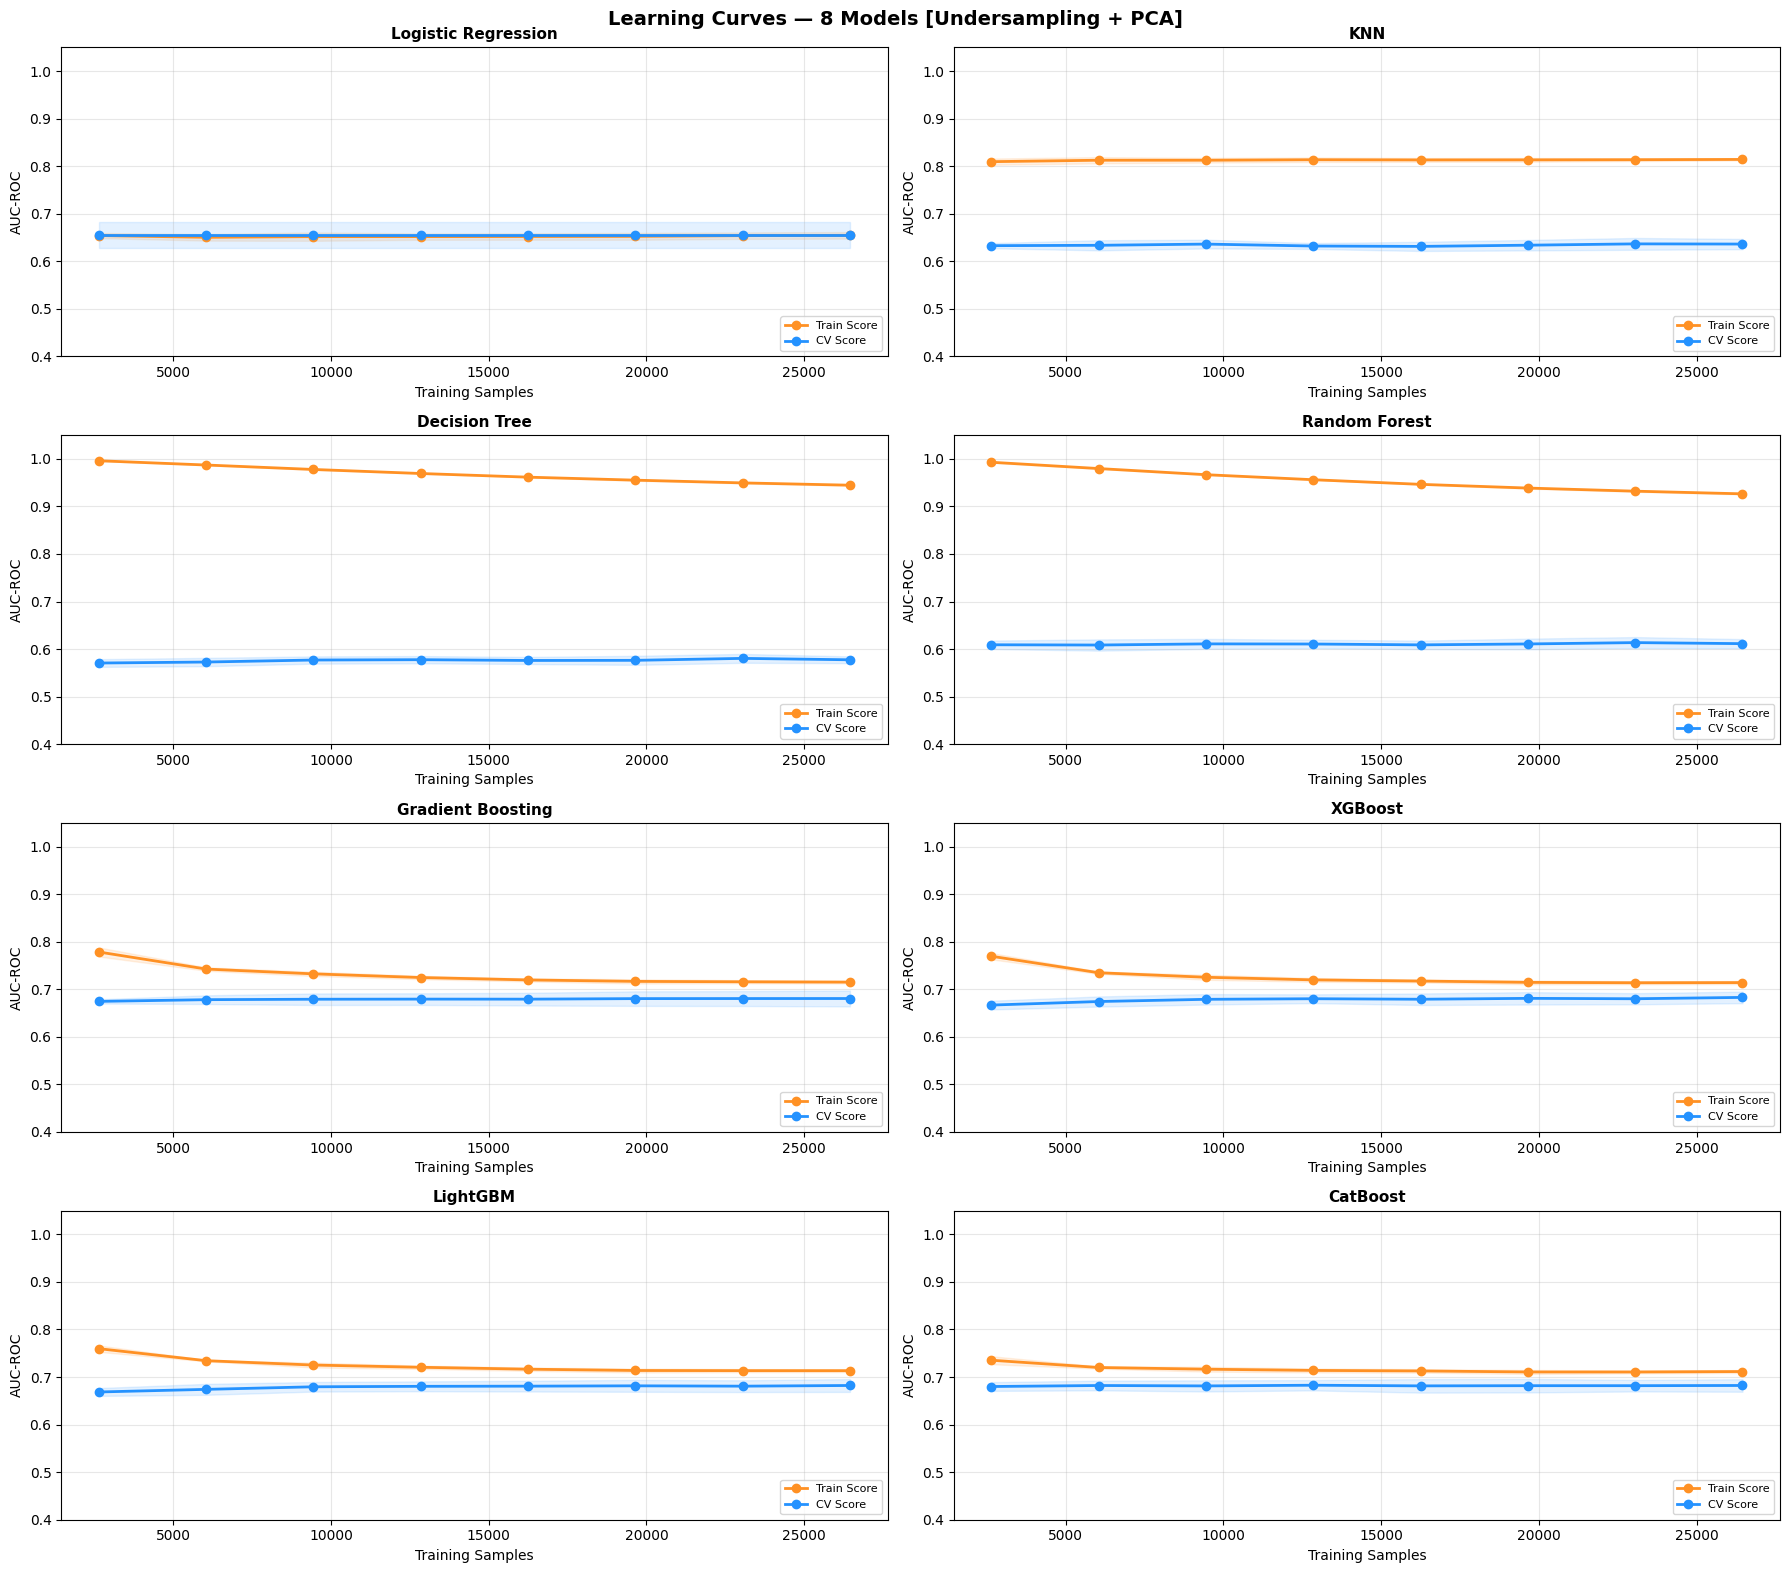


--- Learning Curve Summary [Undersampling] ---


,Model,Strategy,Train AUC (end),CV AUC (end),Gap,Diagnosis
5,XGBoost,Undersampling,0.7141,0.6829,0.0312,Good Fit
7,CatBoost,Undersampling,0.7116,0.6823,0.0293,Good Fit
6,LightGBM,Undersampling,0.7134,0.6822,0.0311,Good Fit
4,Gradient Boosting,Undersampling,0.7151,0.6806,0.0345,Good Fit
0,Logistic Regression,Undersampling,0.6547,0.6547,0.0000,Good Fit
1,KNN,Undersampling,0.8143,0.6364,0.1779,Overfitting
3,Random Forest,Undersampling,0.9265,0.6115,0.3150,Overfitting
2,Decision Tree,Undersampling,0.9446,0.5775,0.3671,Overfitting


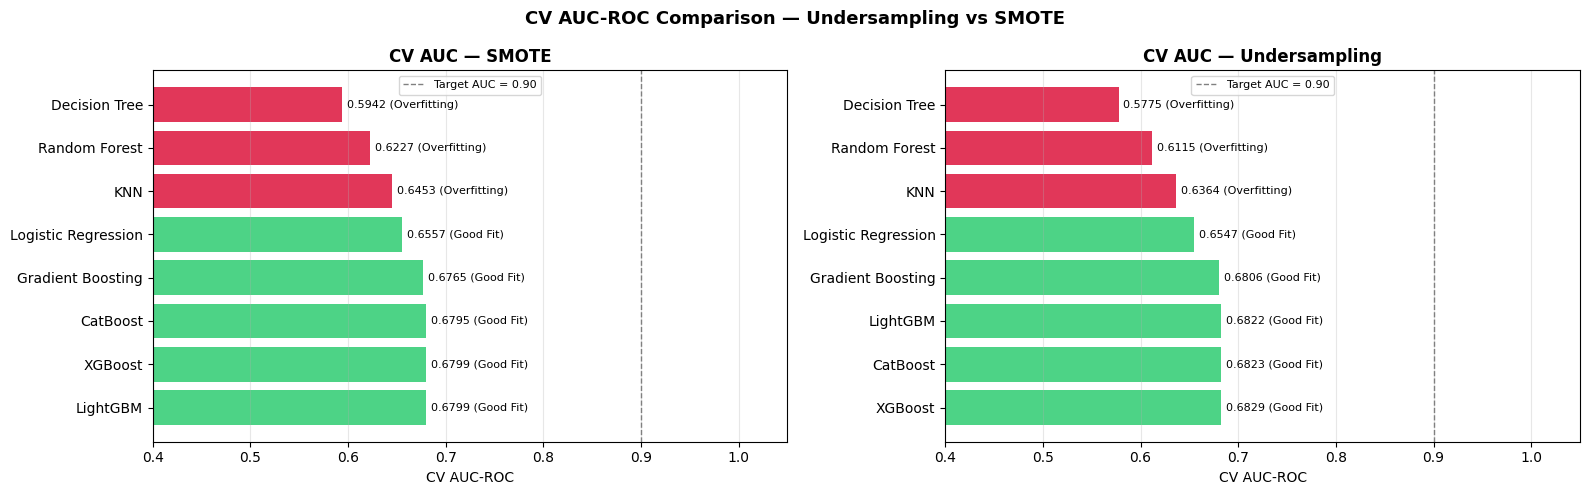


--- Best Model by Learning Curve ---
  Model    : XGBoost
  Strategy : Undersampling
  Train AUC: 0.7141
  CV AUC   : 0.6829
  Gap      : 0.0312
  Diagnosis: Good Fit


In [59]:
"""
IEEE-CIS Fraud Detection — Learning Curves (Part 3.6)
======================================================
Plots learning curves for all 8 models trained with SMOTE + reducer.
Helps identify underfitting, overfitting and the best model.
"""

from sklearn.model_selection import learning_curve

# LEARNING CURVE FUNCTION
def plot_learning_curves(models: dict, X_tr: np.ndarray, Y_tr: np.ndarray,
                         strategy: str, cv: int = 5,
                         train_sizes: np.ndarray = np.linspace(0.1, 1.0, 8)) -> pd.DataFrame:
    """
    Plots learning curves for each model and returns a summary DataFrame.

    Parameters
    ----------
    models : dict
        Dictionary of model name to fitted estimator.
    X_tr : np.ndarray
        Training features (reduced).
    Y_tr : np.ndarray
        Training labels.
    strategy : str
        Balancing strategy label for plot titles.
    cv : int
        Number of cross-validation folds.
    train_sizes : np.ndarray
        Relative or absolute training set sizes to evaluate.

    Returns
    -------
    pd.DataFrame
        Summary with final train/val score and gap per model.
    """
    n_models = len(models)
    n_cols   = 2
    n_rows   = int(np.ceil(n_models / n_cols))

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 4), sharey=False)
    axes      = axes.flatten()

    summary = []

    for i, (name, model) in enumerate(models.items()):
        print(f"  Computing learning curve: {name}...")

        train_sizes_abs, train_scores, val_scores = learning_curve(
            estimator   = model,
            X           = X_tr,
            y           = Y_tr,
            cv          = cv,
            train_sizes = train_sizes,
            scoring     = "roc_auc",
            n_jobs      = -1,
            shuffle     = True,
            random_state= 42,
        )

        train_mean = np.mean(train_scores, axis=1)
        train_std  = np.std(train_scores,  axis=1)
        val_mean   = np.mean(val_scores,   axis=1)
        val_std    = np.std(val_scores,    axis=1)

        ax = axes[i]

        ax.fill_between(train_sizes_abs,
                        train_mean - train_std,
                        train_mean + train_std,
                        alpha=0.12, color="#ff9124")

        ax.fill_between(train_sizes_abs,
                        val_mean - val_std,
                        val_mean + val_std,
                        alpha=0.12, color="#2492ff")

        ax.plot(train_sizes_abs, train_mean, "o-",
                color="#ff9124", linewidth=2, label="Train Score")
        ax.plot(train_sizes_abs, val_mean,   "o-",
                color="#2492ff", linewidth=2, label="CV Score")

        ax.set_title(f"{name}", fontsize=11, fontweight="bold")
        ax.set_xlabel("Training Samples")
        ax.set_ylabel("AUC-ROC")
        ax.legend(loc="lower right", fontsize=8)
        ax.grid(True, alpha=0.3)
        ax.set_ylim(0.4, 1.05)

        gap = round(float(train_mean[-1] - val_mean[-1]), 4)
        summary.append({
            "Model":           name,
            "Strategy":        strategy,
            "Train AUC (end)": round(float(train_mean[-1]), 4),
            "CV AUC (end)":    round(float(val_mean[-1]),   4),
            "Gap":             gap,
            "Diagnosis":       "Overfitting" if gap > 0.10
                               else "Underfitting" if val_mean[-1] < 0.65
                               else "Good Fit",
        })

    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)

    plt.suptitle(f"Learning Curves — 8 Models [{strategy} + {reducer_name}]",
                 fontsize=14, fontweight="bold")
    plt.tight_layout()
    plt.show()

    return pd.DataFrame(summary).sort_values("CV AUC (end)", ascending=False)

# LEARNING CURVES — SMOTE
print("=" * 60)
print(f"LEARNING CURVES: SMOTE + {reducer_name}")
print("=" * 60)
df_lc_smote = plot_learning_curves(models, X_smote_red, Y_smote, strategy="SMOTE")

print("\n--- Learning Curve Summary [SMOTE] ---")
display(df_lc_smote)

# LEARNING CURVES — UNDERSAMPLING
print("\n" + "=" * 60)
print(f"LEARNING CURVES: Undersampling + {reducer_name}")
print("=" * 60)
df_lc_under = plot_learning_curves(models, X_under_red, Y_under, strategy="Undersampling")

print("\n--- Learning Curve Summary [Undersampling] ---")
display(df_lc_under)

# PLOT — CV AUC comparison across strategies
df_lc_all = pd.concat([df_lc_smote, df_lc_under], ignore_index=True)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, (strategy, df_s) in zip(axes, df_lc_all.groupby("Strategy")):
    colors = [
        "crimson"   if d == "Overfitting"   else
        "steelblue" if d == "Underfitting"  else
        "#2ecc71"
        for d in df_s["Diagnosis"]
    ]
    ax.barh(df_s["Model"], df_s["CV AUC (end)"], color=colors, alpha=0.85)
    ax.axvline(0.90, color="gray", linestyle="--", linewidth=1, label="Target AUC = 0.90")
    ax.set_title(f"CV AUC — {strategy}", fontsize=12, fontweight="bold")
    ax.set_xlabel("CV AUC-ROC")
    ax.set_xlim(0.4, 1.05)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3, axis="x")

    for j, (_, row) in enumerate(df_s.iterrows()):
        ax.text(row["CV AUC (end)"] + 0.005, j,
                f'{row["CV AUC (end)"]:.4f} ({row["Diagnosis"]})',
                va="center", fontsize=8)

plt.suptitle("CV AUC-ROC Comparison — Undersampling vs SMOTE",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

# BEST MODEL SUMMARY
best_overall = df_lc_all.sort_values("CV AUC (end)", ascending=False).iloc[0]

print("\n--- Best Model by Learning Curve ---")
print(f"  Model    : {best_overall['Model']}")
print(f"  Strategy : {best_overall['Strategy']}")
print(f"  Train AUC: {best_overall['Train AUC (end)']:.4f}")
print(f"  CV AUC   : {best_overall['CV AUC (end)']:.4f}")
print(f"  Gap      : {best_overall['Gap']:.4f}")
print(f"  Diagnosis: {best_overall['Diagnosis']}")

# **Part 8 - Metrics and evaluation of the machine learning model**

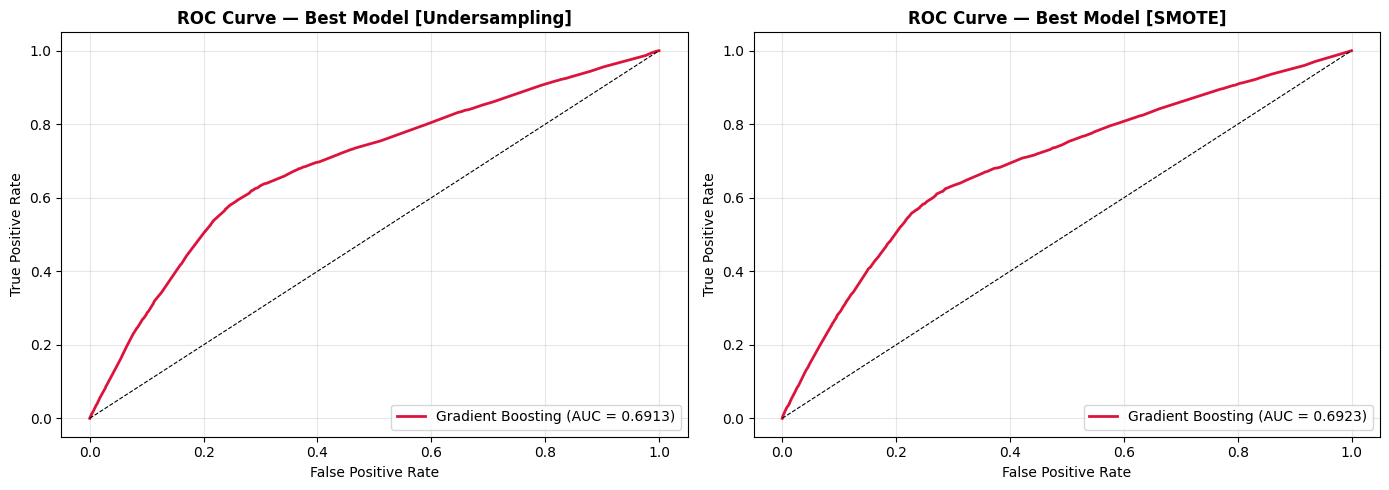

In [60]:
"""
IEEE-CIS Fraud Detection — ROC Curve, Confusion Matrix, Threshold & Save
=========================================================================
Best model ROC curve per strategy, confusion matrices for all 8 models,
threshold optimization and saving all models and metadata to disk.
"""

# ROC CURVE — best model per strategy
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (df_res, X_tr, Y_tr, title) in zip(axes, [
    (df_under_red, X_under_red, Y_under, "Undersampling"),
    (df_smote_red, X_smote_red, Y_smote, "SMOTE"),
]):
    best_name  = df_res.iloc[0]["Model"]
    best_model = models[best_name]
    best_model.fit(X_tr, Y_tr)

    Y_prob      = (
        best_model.predict_proba(X_test_red)[:, 1]
        if hasattr(best_model, "predict_proba")
        else best_model.decision_function(X_test_red)
    )
    fpr, tpr, _ = roc_curve(Y_test, Y_prob)
    auc_val     = roc_auc_score(Y_test, Y_prob)

    ax.plot(fpr, tpr, color="crimson", linewidth=2,
            label=f"{best_name} (AUC = {auc_val:.4f})")
    ax.plot([0, 1], [0, 1], "k--", linewidth=0.8)
    ax.set_title(f"ROC Curve — Best Model [{title}]", fontsize=12, fontweight="bold")
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    ax.legend(loc="lower right")
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

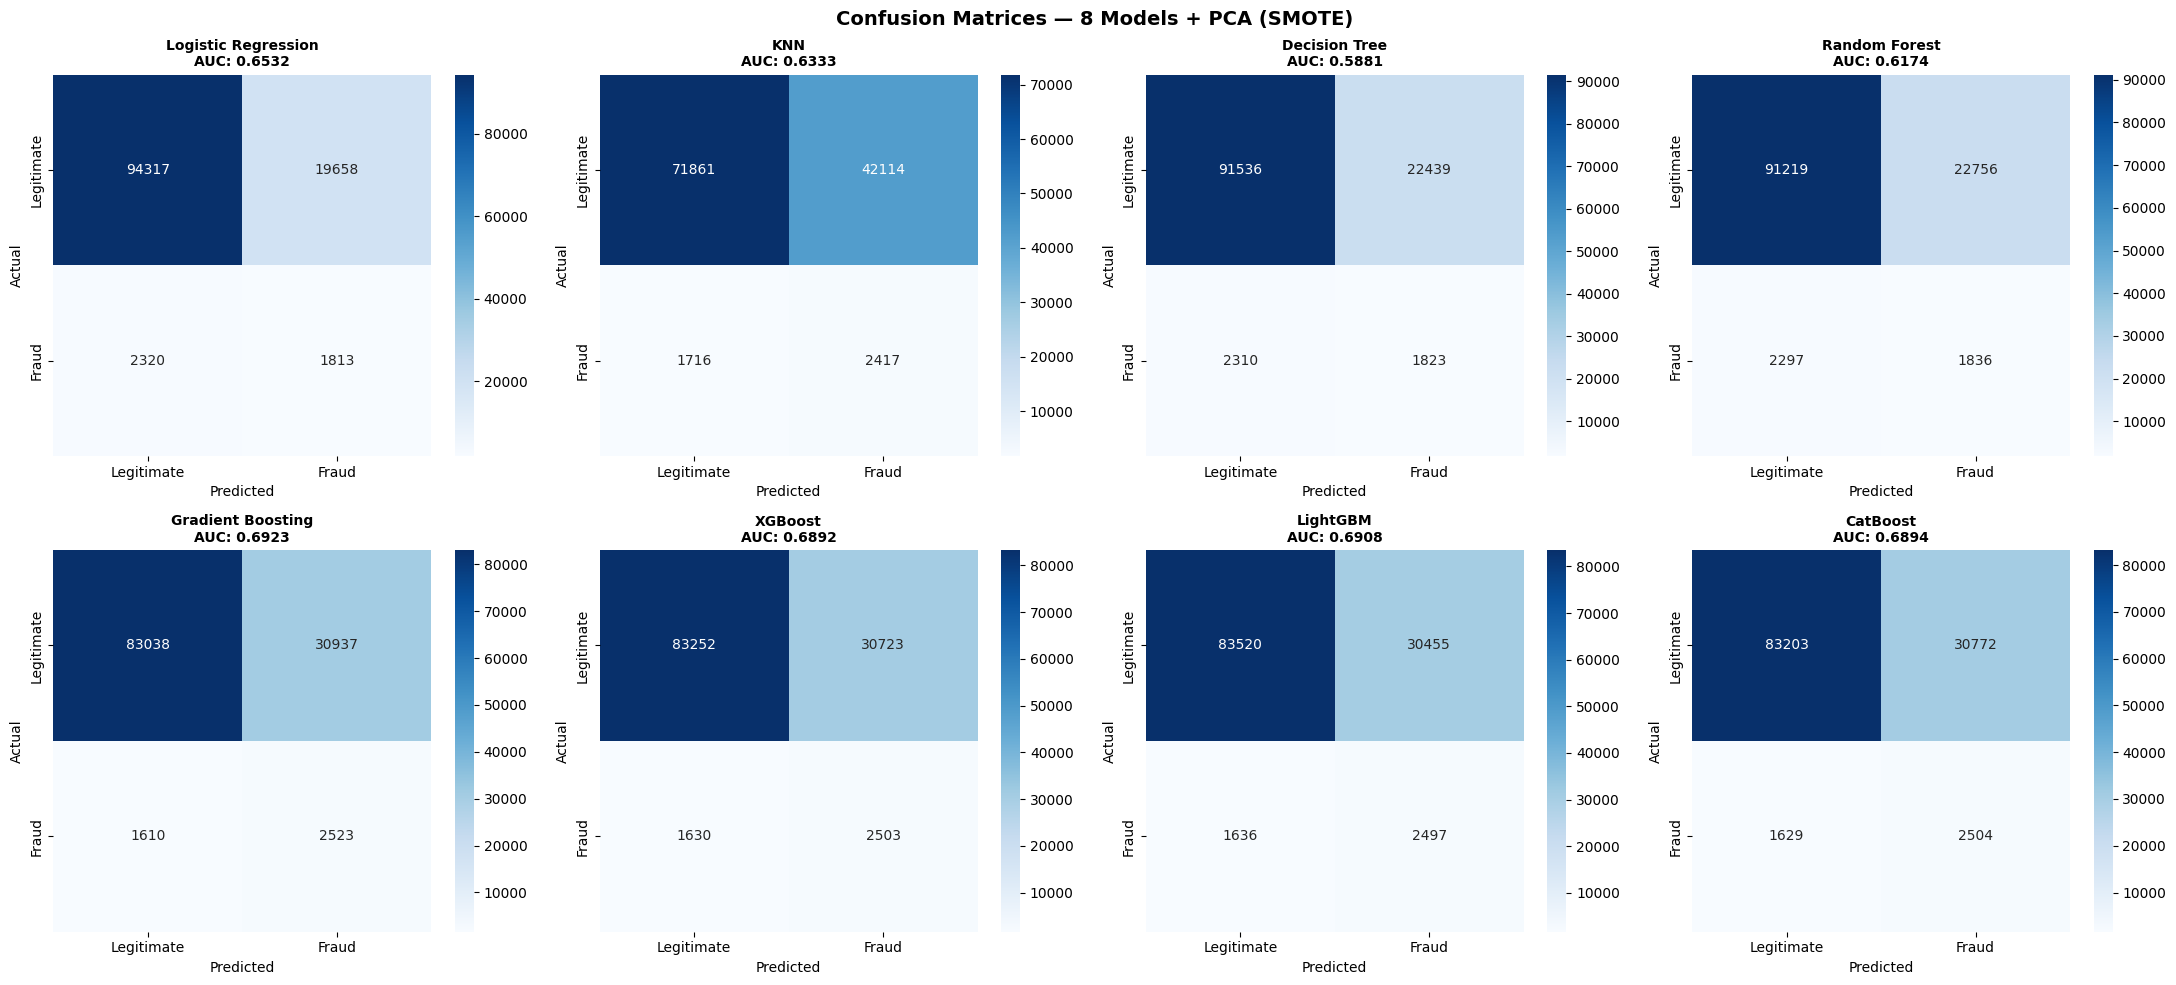

In [61]:
# CONFUSION MATRICES — 8 models with SMOTE + reducer
fig, axes = plt.subplots(2, 4, figsize=(22, 10))
axes      = axes.flatten()

for i, (name, model) in enumerate(models.items()):
    model.fit(X_smote_red, Y_smote)
    Y_pred    = model.predict(X_test_red)
    cm        = confusion_matrix(Y_test, Y_pred)
    Y_prob_cm = (
        model.predict_proba(X_test_red)[:, 1]
        if hasattr(model, "predict_proba")
        else model.decision_function(X_test_red)
    )

    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=axes[i],
                xticklabels=["Legitimate", "Fraud"],
                yticklabels=["Legitimate", "Fraud"])
    axes[i].set_title(
        f"{name}\nAUC: {roc_auc_score(Y_test, Y_prob_cm):.4f}",
        fontsize=10, fontweight="bold"
    )
    axes[i].set_xlabel("Predicted")
    axes[i].set_ylabel("Actual")

plt.suptitle(f"Confusion Matrices — 8 Models + {reducer_name} (SMOTE)",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

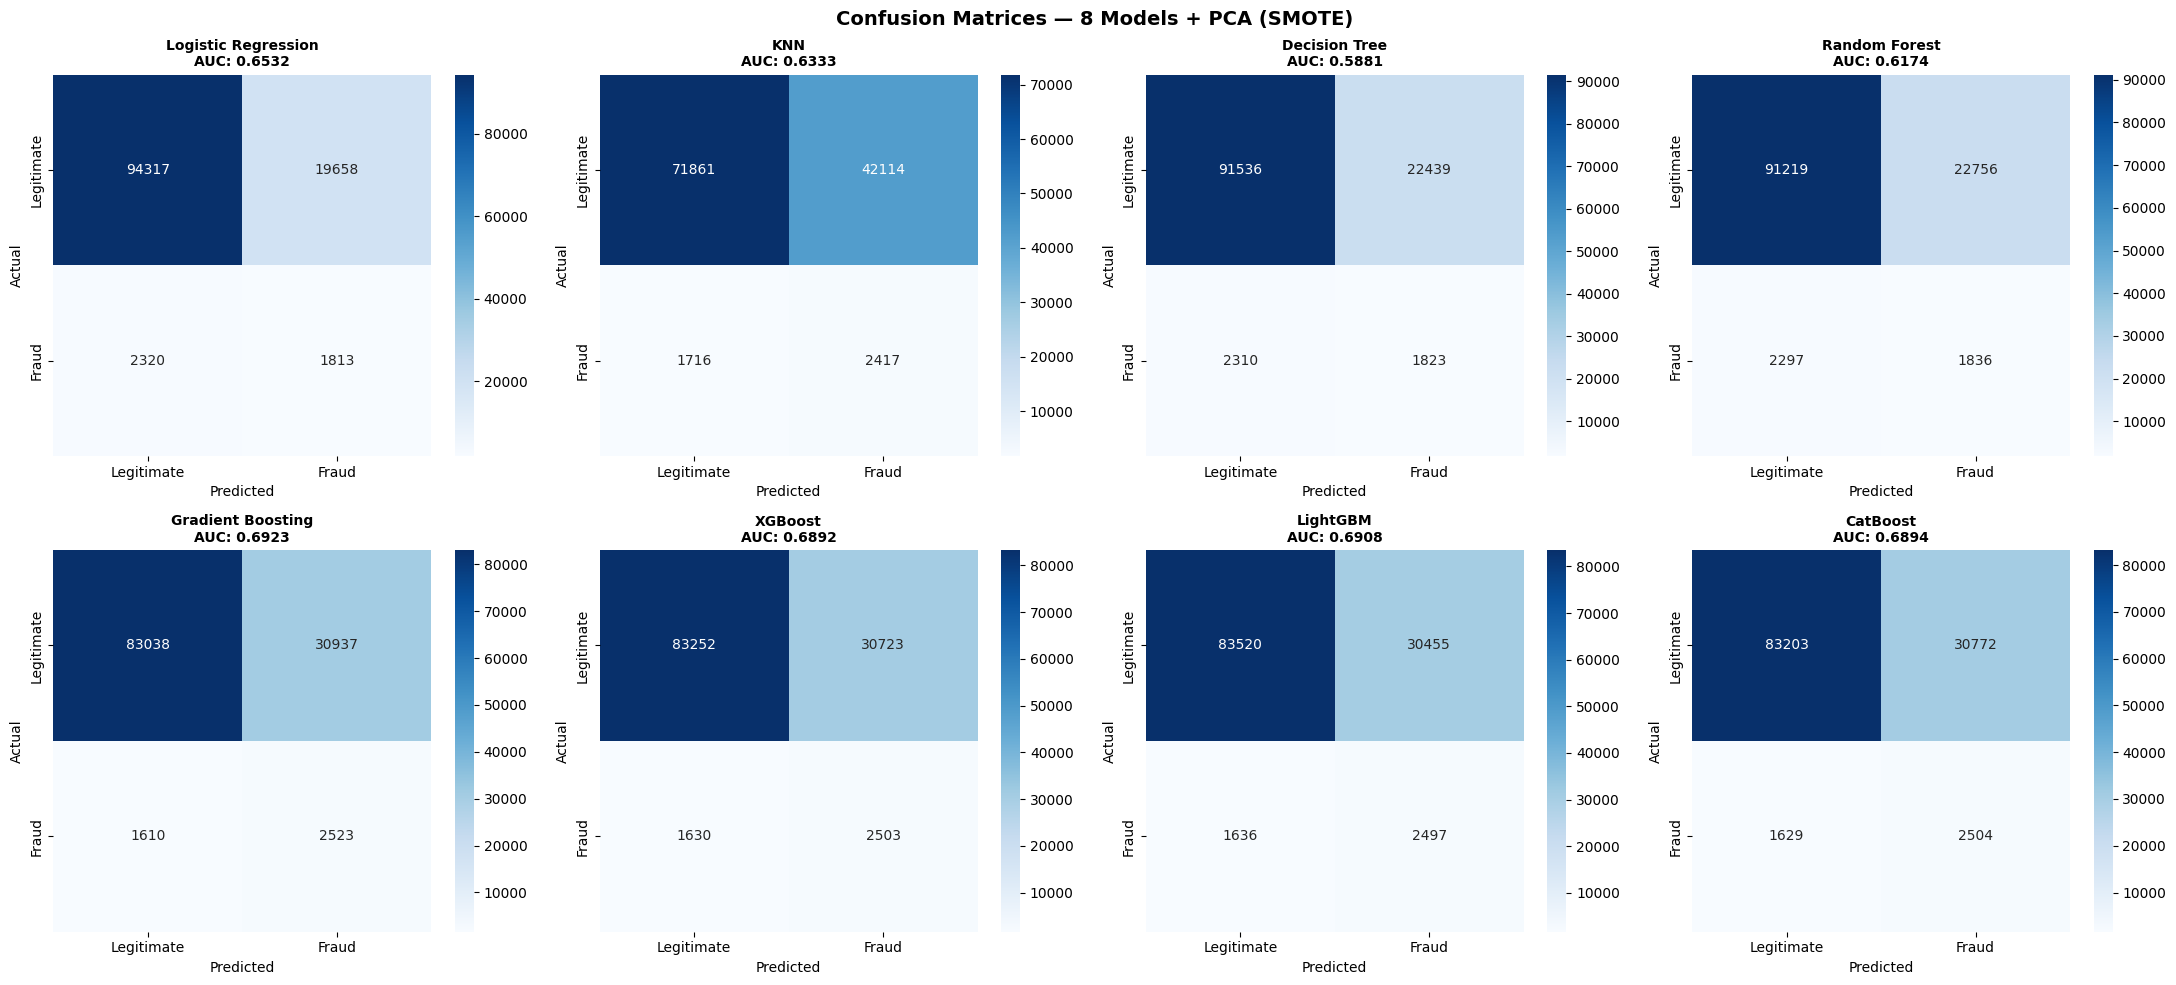

In [62]:
# CONFUSION MATRICES — 8 models with SMOTE + reducer
fig, axes = plt.subplots(2, 4, figsize=(22, 10))
axes      = axes.flatten()

for i, (name, model) in enumerate(models.items()):
    model.fit(X_smote_red, Y_smote)
    Y_pred    = model.predict(X_test_red)
    cm        = confusion_matrix(Y_test, Y_pred)
    Y_prob_cm = (
        model.predict_proba(X_test_red)[:, 1]
        if hasattr(model, "predict_proba")
        else model.decision_function(X_test_red)
    )

    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=axes[i],
                xticklabels=["Legitimate", "Fraud"],
                yticklabels=["Legitimate", "Fraud"])
    axes[i].set_title(
        f"{name}\nAUC: {roc_auc_score(Y_test, Y_prob_cm):.4f}",
        fontsize=10, fontweight="bold"
    )
    axes[i].set_xlabel("Predicted")
    axes[i].set_ylabel("Actual")

plt.suptitle(f"Confusion Matrices — 8 Models + {reducer_name} (SMOTE)",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

In [63]:
# CLASSIFICATION REPORT — best overall model
best_overall  = df_final.iloc[0]
best_name     = best_overall["Model"]
best_strategy = best_overall["Strategy"]

X_tr_final = X_smote_red if best_strategy == "SMOTE" else X_under_red
Y_tr_final = Y_smote     if best_strategy == "SMOTE" else Y_under

models[best_name].fit(X_tr_final, Y_tr_final)
Y_pred_final = models[best_name].predict(X_test_red)

print(f"\n--- Classification Report — Best Model: {best_name} [{best_strategy}] ---")
print(classification_report(Y_test, Y_pred_final, target_names=["Legitimate", "Fraud"]))


--- Classification Report — Best Model: Gradient Boosting [SMOTE] ---
              precision    recall  f1-score   support

  Legitimate       0.98      0.73      0.84    113975
       Fraud       0.08      0.61      0.13      4133

    accuracy                           0.72    118108
   macro avg       0.53      0.67      0.49    118108
weighted avg       0.95      0.72      0.81    118108



# **Part 9 - Machine Learning Model 1 (Optimized Metrics)**

In [64]:
# THRESHOLD OPTIMIZATION
"""
IEEE-CIS Fraud Detection — Threshold Optimization & Final Analysis
==================================================================
Optimizes the decision threshold to maximize F1 score for the Fraud class.
Compares thresholds by Precision, Recall, F1 and AUC-ROC.
"""

# BEST MODEL — Gradient Boosting trained with SMOTE + reducer
best_name  = "Gradient Boosting"
best_model = models[best_name]
best_model.fit(X_smote_red, Y_smote)

Y_prob = best_model.predict_proba(X_test_red)[:, 1]

# PRECISION-RECALL CURVE — find best threshold by F1
precision_arr, recall_arr, thresholds_arr = precision_recall_curve(Y_test, Y_prob)

f1_arr         = 2 * (precision_arr * recall_arr) / (precision_arr + recall_arr + 1e-8)
best_idx       = np.argmax(f1_arr)
best_threshold = thresholds_arr[best_idx]
best_f1        = f1_arr[best_idx]

print(f"Optimized threshold (max F1 Fraud): {best_threshold:.4f}")
print(f"F1 at optimized threshold          : {best_f1:.4f}")


Optimized threshold (max F1 Fraud): 0.6886
F1 at optimized threshold          : 0.1459


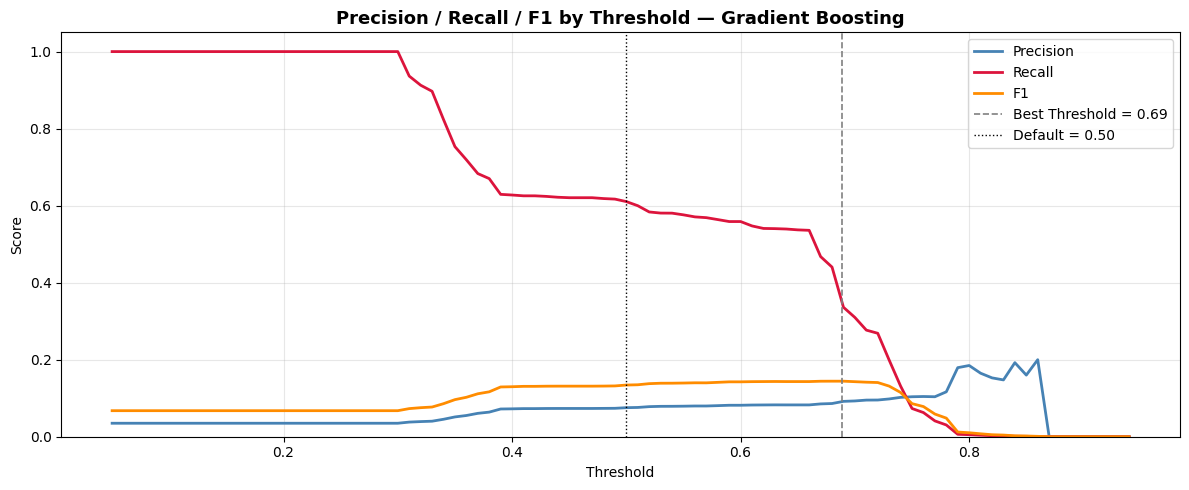

In [65]:
# EVALUATION ACROSS THRESHOLD RANGE
threshold_range   = np.arange(0.05, 0.95, 0.01)
threshold_results = []

for t in threshold_range:
    Y_pred_t = (Y_prob >= t).astype(int)
    threshold_results.append({
        "Threshold": round(t, 2),
        "Precision": round(precision_score(Y_test, Y_pred_t, zero_division=0), 4),
        "Recall":    round(recall_score(Y_test, Y_pred_t, zero_division=0), 4),
        "F1":        round(f1_score(Y_test, Y_pred_t, zero_division=0), 4),
        "Accuracy":  round(accuracy_score(Y_test, Y_pred_t), 4),
    })

df_thresh = pd.DataFrame(threshold_results)

# PLOT — Precision, Recall, F1 by threshold
fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(df_thresh["Threshold"], df_thresh["Precision"], label="Precision", color="steelblue",  linewidth=2)
ax.plot(df_thresh["Threshold"], df_thresh["Recall"],    label="Recall",    color="crimson",    linewidth=2)
ax.plot(df_thresh["Threshold"], df_thresh["F1"],        label="F1",        color="darkorange", linewidth=2)
ax.axvline(best_threshold, color="gray",  linestyle="--", linewidth=1.2,
           label=f"Best Threshold = {best_threshold:.2f}")
ax.axvline(0.5,            color="black", linestyle=":",  linewidth=1,
           label="Default = 0.50")
ax.set_title(f"Precision / Recall / F1 by Threshold — {best_name}",
             fontsize=13, fontweight="bold")
ax.set_xlabel("Threshold")
ax.set_ylabel("Score")
ax.set_ylim(0, 1.05)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

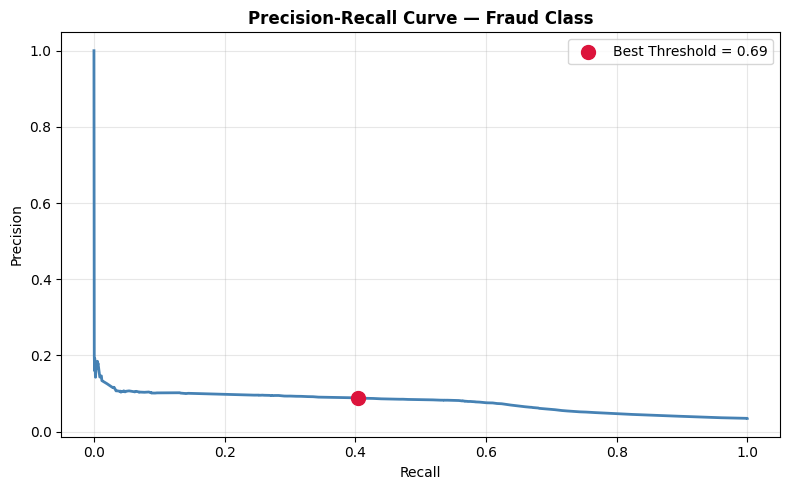

In [66]:
# PLOT — Precision-Recall Curve
fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(recall_arr, precision_arr, color="steelblue", linewidth=2)
ax.scatter(recall_arr[best_idx], precision_arr[best_idx],
           color="crimson", s=100, zorder=5,
           label=f"Best Threshold = {best_threshold:.2f}")
ax.set_title("Precision-Recall Curve — Fraud Class", fontsize=12, fontweight="bold")
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

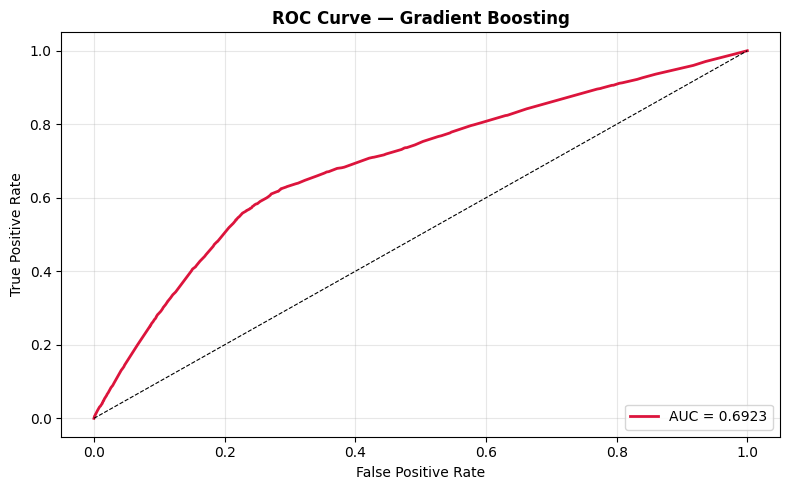

In [67]:
# PLOT — ROC Curve
fpr, tpr, _ = roc_curve(Y_test, Y_prob)
auc_val     = roc_auc_score(Y_test, Y_prob)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(fpr, tpr, color="crimson", linewidth=2, label=f"AUC = {auc_val:.4f}")
ax.plot([0, 1], [0, 1], "k--", linewidth=0.8)
ax.set_title(f"ROC Curve — {best_name}", fontsize=12, fontweight="bold")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.legend(loc="lower right")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

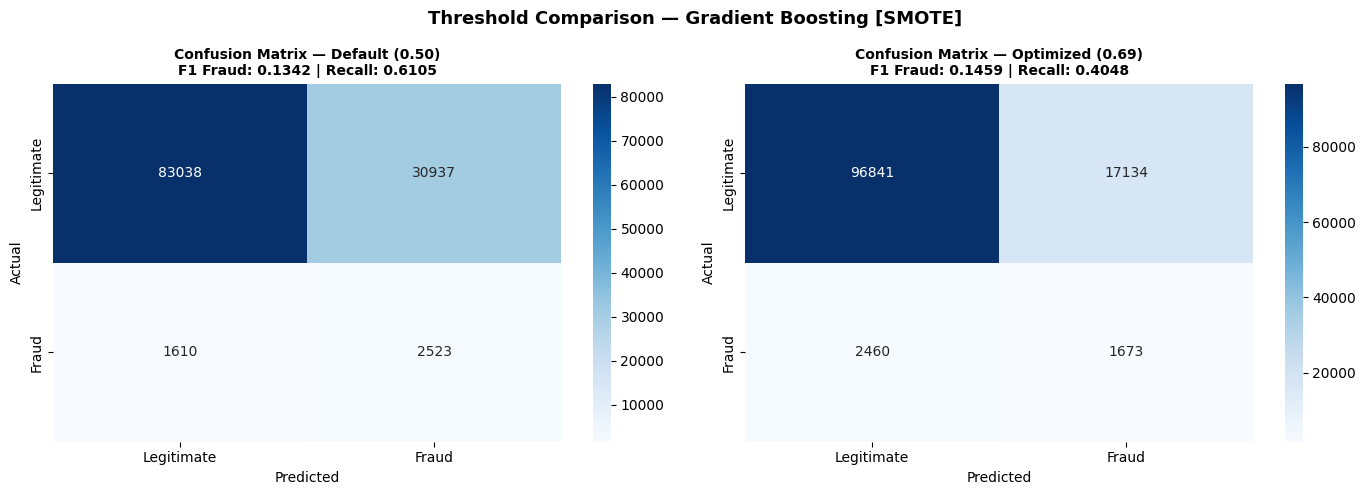

In [68]:
# COMPARISON — default threshold 0.5 vs optimized threshold
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (label, t) in zip(axes, [
    ("Default (0.50)", 0.5),
    (f"Optimized ({best_threshold:.2f})", best_threshold)
]):
    Y_pred_t = (Y_prob >= t).astype(int)
    cm       = confusion_matrix(Y_test, Y_pred_t)

    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
                xticklabels=["Legitimate", "Fraud"],
                yticklabels=["Legitimate", "Fraud"])
    ax.set_title(
        f"Confusion Matrix — {label}\n"
        f"F1 Fraud: {f1_score(Y_test, Y_pred_t, zero_division=0):.4f} | "
        f"Recall: {recall_score(Y_test, Y_pred_t, zero_division=0):.4f}",
        fontsize=10, fontweight="bold"
    )
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.suptitle(f"Threshold Comparison — {best_name} [SMOTE]",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

In [69]:
# CLASSIFICATION REPORT — optimized threshold
Y_pred_optimized = (Y_prob >= best_threshold).astype(int)

print(f"\n--- Classification Report — Optimized Threshold ({best_threshold:.4f}) ---")
print(classification_report(Y_test, Y_pred_optimized, target_names=["Legitimate", "Fraud"]))


--- Classification Report — Optimized Threshold (0.6886) ---
              precision    recall  f1-score   support

  Legitimate       0.98      0.85      0.91    113975
       Fraud       0.09      0.40      0.15      4133

    accuracy                           0.83    118108
   macro avg       0.53      0.63      0.53    118108
weighted avg       0.94      0.83      0.88    118108



In [70]:
# SAVE MODELS
"""
IEEE-CIS Fraud Detection — Save Trained Models
===============================================
Saves all 8 models, the PCA reducer and the optimized threshold
to disk using joblib. Organized in a directory structure.
"""

# OUTPUT DIRECTORY
SAVE_DIR = "/kaggle/working/models"
os.makedirs(SAVE_DIR, exist_ok=True)

# TIMESTAMP
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

# SAVE REDUCER
reducer_path = os.path.join(SAVE_DIR, f"reducer_{reducer_name.lower()}_{timestamp}.pkl")
joblib.dump(reducer, reducer_path)
print(f"Reducer saved : {reducer_path}")

# SAVE 8 MODELS — loop
models_paths = {}

for name, model in models.items():
    file_name  = name.lower().replace(" ", "_")
    model_path = os.path.join(SAVE_DIR, f"{file_name}_{timestamp}.pkl")
    joblib.dump(model, model_path)
    models_paths[name] = model_path
    print(f"Model saved   : {model_path}")

# SAVE OPTIMIZED THRESHOLD + METADATA
metadata = {
    "timestamp":          timestamp,
    "reducer":            reducer_name,
    "n_components":       int(n_components),
    "variance_threshold": VARIANCE_THRESHOLD,
    "best_model":         best_name,
    "best_strategy":      "SMOTE",
    "best_threshold":     round(float(best_threshold), 6),
    "best_auc_roc":       round(float(auc_val), 6),
    "models_paths":       models_paths,
    "reducer_path":       reducer_path,
}

metadata_path = os.path.join(SAVE_DIR, f"metadata_{timestamp}.json")
with open(metadata_path, "w") as f:
    json.dump(metadata, f, indent=4)

print(f"Metadata saved: {metadata_path}")

# SAVE FINAL RANKING
ranking_path = os.path.join(SAVE_DIR, f"final_ranking_{timestamp}.csv")
df_final.to_csv(ranking_path, index=False)
print(f"Ranking saved : {ranking_path}")

# VERIFICATION — list saved files
print("\n--- Files saved in /kaggle/working/models ---")
for file in sorted(os.listdir(SAVE_DIR)):
    file_path = os.path.join(SAVE_DIR, file)
    size_mb   = os.path.getsize(file_path) / 1e6
    print(f"  {file:<55} {size_mb:.2f} MB")

# LOAD TEST — validates all models load correctly
print("\n--- Validating model loading ---")

reducer_loaded = joblib.load(reducer_path)
print(f"Reducer loaded : {type(reducer_loaded).__name__} — OK")

for name, path in models_paths.items():
    model_loaded  = joblib.load(path)
    Y_pred_check  = model_loaded.predict(X_test_red[:5])
    print(f"  {name:<25} loaded — predict OK | output: {Y_pred_check}")

print("\nAll models validated successfully.")

Reducer saved : /kaggle/working/models/reducer_pca_20260419_080324.pkl
Model saved   : /kaggle/working/models/logistic_regression_20260419_080324.pkl
Model saved   : /kaggle/working/models/knn_20260419_080324.pkl
Model saved   : /kaggle/working/models/decision_tree_20260419_080324.pkl
Model saved   : /kaggle/working/models/random_forest_20260419_080324.pkl
Model saved   : /kaggle/working/models/gradient_boosting_20260419_080324.pkl
Model saved   : /kaggle/working/models/xgboost_20260419_080324.pkl
Model saved   : /kaggle/working/models/lightgbm_20260419_080324.pkl
Model saved   : /kaggle/working/models/catboost_20260419_080324.pkl
Metadata saved: /kaggle/working/models/metadata_20260419_080324.json
Ranking saved : /kaggle/working/models/final_ranking_20260419_080324.csv

--- Files saved in /kaggle/working/models ---
  catboost_20260419_080324.pkl                            0.12 MB
  decision_tree_20260419_080324.pkl                       24.39 MB
  final_ranking_20260419_080324.csv    

In [71]:
# FINAL SUMMARY TABLE
print("\n--- Save Summary ---")
save_summary = pd.DataFrame([
    {"File": os.path.basename(p), "Size MB": round(os.path.getsize(p) / 1e6, 2)}
    for p in list(models_paths.values()) + [reducer_path, metadata_path, ranking_path]
])
display(save_summary)


--- Save Summary ---


,File,Size MB
0,logistic_regression_20260419_080324.pkl,0.00
1,knn_20260419_080324.pkl,30.75
2,decision_tree_20260419_080324.pkl,24.39
3,random_forest_20260419_080324.pkl,1587.11
4,gradient_boosting_20260419_080324.pkl,0.14
5,xgboost_20260419_080324.pkl,0.23
6,lightgbm_20260419_080324.pkl,0.36
7,catboost_20260419_080324.pkl,0.12
8,reducer_pca_20260419_080324.pkl,0.01
9,metadata_20260419_080324.json,0.00


# **Part 10 - Final metrics**

In [72]:
# COMPARATIVE SUMMARY
print("\n--- Threshold Comparative Summary ---")
for label, t in [
    ("Default (0.50)", 0.5),
    (f"Optimized ({best_threshold:.2f})", best_threshold)
]:
    Y_pred_t = (Y_prob >= t).astype(int)
    print(f"\n{label}")
    print(f"  AUC-ROC  : {auc_val:.4f}")
    print(f"  F1 Fraud : {f1_score(Y_test, Y_pred_t, zero_division=0):.4f}")
    print(f"  Precision: {precision_score(Y_test, Y_pred_t, zero_division=0):.4f}")
    print(f"  Recall   : {recall_score(Y_test, Y_pred_t, zero_division=0):.4f}")
    print(f"  Accuracy : {accuracy_score(Y_test, Y_pred_t):.4f}")


--- Threshold Comparative Summary ---

Default (0.50)
  AUC-ROC  : 0.6923
  F1 Fraud : 0.1342
  Precision: 0.0754
  Recall   : 0.6105
  Accuracy : 0.7244

Optimized (0.69)
  AUC-ROC  : 0.6923
  F1 Fraud : 0.1459
  Precision: 0.0890
  Recall   : 0.4048
  Accuracy : 0.8341
